# UK Biobank — Authorship Analysis

Analysis of the authorship of 20 years of UK Biobank publications.

**Sections**
1. **Setup** — imports, environment, shared formatting dictionary
2. **Data cleaning** — build a tidy *author–paper* long table (one author–paper pair per row)
3. **Geographic distribution** — world map of where authors are based (raw + normalised)
4. **Top institutes** — bar chart of the most prolific institutions
5. **Gender trends over time** — share of authorships by inferred gender
6. **Network collaboration** — final-snapshot co-authorship network

> **Modularisation note.** Functions are written here in the notebook while the
> analysis is still being developed. They are deliberately kept *pure* (they take
> data + the shared `STYLE` dict and return objects / figures) so that, as a final
> step, they can be lifted verbatim into `src/utils/author_utils.py` — mirroring the
> `utils/patent_utils.py` pattern used by `01_analysis_01_patents_analysis_modularized.ipynb`.

## 1. Setup

Imports, working directory, and the **single shared formatting dictionary** (`STYLE`)
that every visualisation in this notebook reads from — colour palette, figure sizes,
font sizes, dpi, colormap.

In [1]:
import os
import sys
import ast
from functools import lru_cache
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import geopandas as gpd
import networkx as nx
from scipy import sparse as sp
import gender_guesser.detector as gender_detector
import nomquamgender as nqg          # larger offline name-gender model (2nd-pass refine)

import warnings
warnings.filterwarnings("ignore")

# Run from the project root so that relative paths ('data/...', 'fig/...') resolve,
# regardless of how many times this cell is run.
ROOT = Path.cwd()
if ROOT.name == "src":
    os.chdir(ROOT.parent)
ROOT = Path.cwd()
print("Working directory:", ROOT)

# Make sure the `src` package dir is importable, then reuse the patent
# country-cleaning helpers (ISO matching already implemented there).
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from utils import patent_utils as patent

Working directory: /Users/valler/Python/RA/20_years_of_ukb


In [2]:
# =============================================================================
# SHARED FORMATTING DICTIONARY  -- every figure reads from this
# =============================================================================
STYLE = {
    # four customised colours (same palette used across the project)
    "colors": ["#B80C09", "#D4AF37", "#6E8B3D", "#345995"],

    # figure sizes
    "figsize": (12, 7),
    "figsize_wide": (14, 7),
    "figsize_map": (14, 8),
    "figsize_network": (12, 12),

    # font sizes
    "title_fs": 16,
    "label_fs": 13,
    "tick_fs": 11,
    "annot_fs": 10,
    "legend_fs": 11,

    # misc
    "dpi": 300,
    "cmap": "ocean",
    "edgecolor": "grey",
    "save": False,            # set True to write figures to fig/authors/
    "savedir": "fig/authors",
}

# semantic colour roles drawn from the 4-colour palette
STYLE["c_primary"]   = STYLE["colors"][3]   # blue
STYLE["c_accent"]    = STYLE["colors"][0]   # red
STYLE["c_gold"]      = STYLE["colors"][1]   # gold
STYLE["c_green"]     = STYLE["colors"][2]   # green
STYLE["gender_colors"] = {"female": STYLE["colors"][0], "male": STYLE["colors"][3],
                          "unknown": "#BBBBBB"}


def apply_style(style=STYLE):
    """Push the shared style into matplotlib rcParams (call once / after edits)."""
    plt.rcParams.update({
        "figure.dpi": 110,            # on-screen
        "savefig.dpi": style["dpi"],  # exported
        "axes.titlesize": style["title_fs"],
        "axes.labelsize": style["label_fs"],
        "xtick.labelsize": style["tick_fs"],
        "ytick.labelsize": style["tick_fs"],
        "legend.fontsize": style["legend_fs"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Sans",
    })
    sns.set_palette(style["colors"])


def extended_palette(n, style=STYLE):
    """N colours interpolated across the 4 brand colours (for >4 categories)."""
    from matplotlib.colors import LinearSegmentedColormap
    if n <= len(style["colors"]):
        return style["colors"][:n]
    cmap = LinearSegmentedColormap.from_list("brand", style["colors"], N=256)
    return [cmap(i / (n - 1)) for i in range(n)]


def savefig(fig, name, style=STYLE):
    """Optionally persist a figure to the configured directory."""
    if style.get("save"):
        outdir = Path(style["savedir"]); outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / f"{name}.pdf", dpi=style["dpi"], bbox_inches="tight")
        print("saved ->", outdir / f"{name}.pdf")


apply_style()
print("Palette:", STYLE["colors"])

Palette: ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']


## 2. Data cleaning — the author–paper long table

We depart from the raw paper-level `df_dimensions.xlsx` and build a tidy
**`df_ap`** table where **each row is one (author, paper) pair**.

An author can appear on many papers,
and we need the per-paper context for *every* downstream analysis:

* geography & institutes → an author's affiliation can differ per paper,
* gender trends → we need the *year* of each authorship,
* network → co-authorship edges are defined *within* a paper.

A one-row-per-author table would throw away exactly this paper context (and the
network could not be rebuilt from it). The long table has ~10<sup>5</sup> rows (≈ the total number of author slots), which is small. We derive the per-author summary (`df_authors`) from it by grouping when needed.

The richest source is the `authors` column — each entry carries the author's
`researcher_id`, name, and **per-paper affiliation** (institution name, grid id,
country, country code). We parse that into `df_ap`.

In [3]:
def parse_listcol(x):
    """Safely parse a stringified list-of-dicts cell into a Python list."""
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            return v if isinstance(v, list) else []
        except Exception:
            return []
    return []


def _norm_name_id(first, last):
    """Synthetic stable id for authors that are missing a researcher_id."""
    f = (first or "").strip().lower()
    l = (last or "").strip().lower()
    return f"name::{f}|{l}" if (f or l) else None


def pick_main_affiliation(author):
    """Choose ONE 'main' affiliation for an author on a paper, and say how.

    Definition (because 38% of author slots list >=2 affiliations, max 26):
    the author's **main institutional home** = the listed affiliation whose grid id
    equals their `current_organization_id` (the principal org Dimensions records for
    them). If that org is absent from this paper's list (or the author has no
    current org), we fall back to the **first-listed** affiliation. Returns
    (affiliation_dict, source) where source ∈ {'current_org','first_listed','none'}.
    """
    affs = author.get("affiliations") or []
    if not affs:
        return {}, "none"
    cur = author.get("current_organization_id")
    if cur:
        for af in affs:
            if isinstance(af, dict) and af.get("id") == cur:
                return af, "current_org"
    return (affs[0] if isinstance(affs[0], dict) else {}), "first_listed"


def build_author_paper_table(df):
    """Explode the `authors` column into one row per (author, paper).

    Returns a long DataFrame with author identity, the paper context (id, year,
    citations) and the *primary* (first) affiliation for that author on that paper.
    """
    rows = []
    for _, r in df.iterrows():
        paper_id = r["id"]
        year = r["year"]
        cited = r.get("times_cited", np.nan)
        for a in parse_listcol(r["authors"]):
            if not isinstance(a, dict):
                continue
            rid = a.get("researcher_id") or _norm_name_id(a.get("first_name"), a.get("last_name"))
            if rid is None:
                continue  # cannot identify this author at all
            aff, aff_source = pick_main_affiliation(a)   # main home, see definition
            rows.append({
                "paper_id": paper_id,
                "year": year,
                "times_cited": cited,
                "author_id": rid,
                "first_name": (a.get("first_name") or "").strip(),
                "last_name": (a.get("last_name") or "").strip(),
                "is_corresponding": bool(a.get("corresponding")),
                "n_affiliations": len(a.get("affiliations") or []),
                "current_org_id": a.get("current_organization_id"),
                "org_name": aff.get("name"),
                "org_grid": aff.get("id"),
                "country": aff.get("country"),
                "country_code": aff.get("country_code"),
                "aff_source": aff_source,   # 'current_org' | 'first_listed' | 'none'
            })
    ap = pd.DataFrame(rows)
    ap["full_name"] = (ap["first_name"] + " " + ap["last_name"]).str.strip()
    # one author can legitimately list the same paper twice (multi-affiliation) ->
    # keep a single (author, paper) row for counting purposes.
    ap = ap.drop_duplicates(subset=["author_id", "paper_id"]).reset_index(drop=True)
    ap["year"] = pd.to_numeric(ap["year"], errors="coerce")
    ap["times_cited"] = pd.to_numeric(ap["times_cited"], errors="coerce").fillna(0)
    return ap


# ---- FOR (Fields of Research, 2020 ANZSRC) -----------------------------------
# Each category_for_2020 entry is {'id', 'name'} where name starts with a numeric
# code: 2-digit = L2 division (e.g. '32 Biomedical and Clinical Sciences'),
# 4-digit = L4 field (e.g. '3212 Ophthalmology and Optometry').
def _split_for_name(name):
    """Return (code, label, level) from a FOR name string, or (None, None, None)."""
    if not isinstance(name, str) or not name.strip():
        return None, None, None
    parts = name.strip().split(" ", 1)
    code = parts[0]
    label = parts[1].strip() if len(parts) > 1 else ""
    if code.isdigit() and len(code) == 2:
        return code, label, "L2"
    if code.isdigit() and len(code) == 4:
        return code, label, "L4"
    return None, None, None


def build_for_lookup(df):
    """Global 2-digit division code -> division label, harvested from the data."""
    lut = {}
    for cats in df["category_for_2020"].apply(parse_listcol):
        for c in cats:
            if isinstance(c, dict):
                code, label, level = _split_for_name(c.get("name"))
                if level == "L2" and code not in lut:
                    lut[code] = label
    return lut


def build_paper_for_table(df, div_lut):
    """One row per paper with the FULL set of FOR L2 divisions and L4 fields.

    `category_for_2020` is an UNORDERED multi-label set — each entry has only a
    name + id (no relevance score) and the list order is not meaningful — so we do
    NOT pick a single "primary" division. We keep every division in `for_l2` and every
    field in `for_l4`; the parent division of any L4-only code is folded into `for_l2`
    so the division set is complete. Papers with no usable category get empty lists.
    """
    rows = []
    for _, r in df.iterrows():
        cats = parse_listcol(r["category_for_2020"])
        l2, l4 = set(), set()
        for c in cats:
            if not isinstance(c, dict):
                continue
            code, label, level = _split_for_name(c.get("name"))
            if level == "L2":
                l2.add(label)
            elif level == "L4":
                l4.add(label)
                parent = div_lut.get(code[:2])      # ensure parent division is present
                if parent:
                    l2.add(parent)
        rows.append({
            "paper_id": r["id"],
            "for_l2": sorted(l2),
            "for_l4": sorted(l4),
            "n_for_l2": len(l2),
        })
    return pd.DataFrame(rows)

In [4]:
# =============================================================================
# AFFILIATION ENRICHMENT — backfill missing institute info via the grid identity
# =============================================================================
# A GRID id uniquely identifies an institution; org_name / country / country_code are
# its *attributes*. Dimensions sometimes records an affiliation as a bare department
# string (no grid, no country) or omits it entirely, so a per-paper row can lack a
# country even though the SAME institution is fully described elsewhere in the corpus.
# We rebuild the canonical grid -> attributes table once and use it to fill those gaps
# BEFORE any geographic analysis or missing-data handling.
def build_grid_lookup(df):
    """grid id -> {org_name, country, country_code}, most-common across EVERY
    affiliation in the corpus. The grid id is an institute's unique key; the other
    fields are attributes, harvested wherever they ARE recorded so we can backfill
    rows where they are not. (Also reused in the df_authors section.)"""
    name, country, cc = defaultdict(Counter), defaultdict(Counter), defaultdict(Counter)
    for al in df["authors"]:
        for a in al:
            if not isinstance(a, dict):
                continue
            for af in (a.get("affiliations") or []):
                if not isinstance(af, dict):
                    continue
                gid = af.get("id")
                if not gid:
                    continue
                if af.get("name"):         name[gid][af["name"]] += 1
                if af.get("country"):      country[gid][af["country"]] += 1
                if af.get("country_code"): cc[gid][af["country_code"]] += 1
    def top(counter, g):
        return counter[g].most_common(1)[0][0] if counter.get(g) else None
    grids = set(name) | set(country) | set(cc)
    return {g: {"org_name": top(name, g), "country": top(country, g),
                "country_code": top(cc, g)} for g in grids}


def enrich_affiliations(ap, grid_lut):
    """Fill missing institute fields on df_ap using the grid identity, in two passes.

    The tuple (org_grid, org_name, country, country_code) describes ONE institution,
    keyed by the grid id; `current_organization_id` is the author's principal org (also
    a grid id, constant across their papers). Both passes are keyed on a grid id:

      1. COMPLETE  — a row that already carries an `org_grid` but is missing
         org_name / country / country_code gets them from grid_lut[org_grid] (the same
         institution recorded more fully on other papers).
      2. BACKFILL  — a row whose per-paper affiliation carries NO grid id (a bare
         department string, or no affiliation at all) but whose author has a resolvable
         `current_organization_id` adopts that principal org as this authorship's
         institution: org_grid <- current_org_id and org_name/country/country_code <-
         grid_lut. This resolves un-gridded department strings to their parent institute
         AND places authorships that had no affiliation at all.

    Provenance: `aff_source` gains 'grid_completed' / 'current_org_backfill', and an
    `aff_enriched` flag marks every touched row. Rows still unresolved keep their
    original values (excluded from the map only, exactly as before enrichment).
    """
    ap = ap.copy()
    lut = pd.DataFrame(grid_lut).T[["org_name", "country", "country_code"]]
    ATTR = ["org_name", "country", "country_code"]
    ap["aff_enriched"] = False

    # pass 1 -- COMPLETE from the row's own grid
    have = ap["org_grid"].notna()
    for a in ATTR:
        m = have & ap[a].isna()
        vals = ap.loc[m, "org_grid"].map(lut[a])
        ap.loc[m, a] = vals
        ap.loc[m & vals.notna(), "aff_enriched"] = True
    completed = ap["aff_enriched"] & ap["aff_source"].isin(["first_listed", "none"])
    ap.loc[completed, "aff_source"] = "grid_completed"

    # pass 2 -- BACKFILL from the author's current organisation (their principal org)
    bf = ap["org_grid"].isna() & ap["current_org_id"].isin(lut.index)
    srcid = ap.loc[bf, "current_org_id"]
    ap.loc[bf, "org_grid"] = srcid.values
    for a in ATTR:
        ap.loc[bf, a] = srcid.map(lut[a]).values
    ap.loc[bf, "aff_source"] = "current_org_backfill"
    ap.loc[bf, "aff_enriched"] = True
    return ap


In [5]:
# Load the raw paper-level data.
# Reading the 73 MB .xlsx (~10s) and parsing the nested `authors` column (~10s) are
# the slow steps, so we cache the parsed frame to a pickle keyed on the source file's
# mtime: the first run pays ~20s, later runs reload in ~1s (delete the .pkl or edit
# the source to invalidate).
NEEDED_COLS = ["id", "year", "times_cited", "authors", "researchers",
               "category_for_2020", "research_org_country_names"]

def load_dimensions(path="data/df_dimensions.xlsx", cols=NEEDED_COLS, use_cache=True):
    cache = Path(path).with_suffix(".parsed.pkl")
    if use_cache and cache.exists() and cache.stat().st_mtime >= Path(path).stat().st_mtime:
        return pd.read_pickle(cache)
    d = pd.read_excel(path, usecols=cols)
    d["authors"] = d["authors"].apply(parse_listcol)   # expensive parse, done once
    if use_cache:
        d.to_pickle(cache)
    return d

df = load_dimensions()
print(f"Papers: {len(df):,}  |  years {int(df['year'].min())}-{int(df['year'].max())}")

# Build the author-paper long table
df_ap = build_author_paper_table(df)

# Attach each paper's Fields of Research (FOR 2020): the FULL L2/L4 sets (no primary).
div_lut = build_for_lookup(df)
paper_for = build_paper_for_table(df, div_lut)
df_ap = df_ap.merge(paper_for, on="paper_id", how="left")
df_ap["for_l2"] = df_ap["for_l2"].apply(lambda v: v if isinstance(v, list) else [])
df_ap["for_l4"] = df_ap["for_l4"].apply(lambda v: v if isinstance(v, list) else [])
df_ap["n_for_l2"] = df_ap["for_l2"].apply(len)

# Affiliation enrichment -- run BEFORE any geography / missing-data step. Backfill
# the institute fields (org_grid, org_name, country, country_code) from the corpus-
# wide grid identity so rows whose per-paper affiliation merely OMITS the country (a
# bare department string, or no affiliation) are resolved to their institute and
# placed, rather than silently dropped from the map. grid_lut is reused by df_authors.
grid_lut = build_grid_lookup(df)
_cmiss0 = int(df_ap["country"].isna().sum())
df_ap = enrich_affiliations(df_ap, grid_lut)
_cmiss1 = int(df_ap["country"].isna().sum())

n_divs = len({d for L in paper_for["for_l2"] for d in L})
print(f"Author-paper rows  : {len(df_ap):,}")
print(f"Unique authors     : {df_ap['author_id'].nunique():,}")
print(f"Unique papers      : {df_ap['paper_id'].nunique():,}")
print(f"Distinct FOR L2 divisions: {n_divs}")
print(f"Papers with >=2 L2 : {(paper_for['n_for_l2']>=2).sum():,} "
      f"({100*(paper_for['n_for_l2']>=2).mean():.1f}%)")
print(f"Papers with no L2  : {(paper_for['n_for_l2']==0).sum():,}")
print(f"Affiliations enriched (grid identity): {int(df_ap['aff_enriched'].sum()):,} "
      f"| country-missing rows {_cmiss0:,} -> {_cmiss1:,}")
df_ap[["paper_id", "author_id", "full_name", "org_name", "country",
       "for_l2", "for_l4"]].head()

Papers: 10,846  |  years 2013-2025


Author-paper rows  : 99,594
Unique authors     : 39,768
Unique papers      : 10,379
Distinct FOR L2 divisions: 19
Papers with >=2 L2 : 3,496 (32.2%)
Papers with no L2  : 11
Affiliations enriched (grid identity): 2,910 | country-missing rows 3,443 -> 1,778


,paper_id,author_id,full_name,org_name,country,for_l2,for_l4
0,pub.1142697354,ur.012214661411.72,Xianwen Shang,Guangdong Provincial People’s Hospital,China,[Biomedical and Clinical Sciences],[Ophthalmology and Optometry]
1,pub.1142697354,ur.01252040141.98,Zhuoting Zhu,Guangdong Provincial People’s Hospital,China,[Biomedical and Clinical Sciences],[Ophthalmology and Optometry]
2,pub.1142697354,ur.011057763623.08,Xueli Zhang,Guangdong Provincial People’s Hospital,China,[Biomedical and Clinical Sciences],[Ophthalmology and Optometry]
3,pub.1142697354,ur.010206043100.33,Yu Huang,Guangdong Provincial People’s Hospital,China,[Biomedical and Clinical Sciences],[Ophthalmology and Optometry]
4,pub.1142697354,ur.011464175105.44,Zachary Tan,Centre for Eye Research Australia,Australia,[Biomedical and Clinical Sciences],[Ophthalmology and Optometry]


In [6]:
df_ap.to_pickle("data/author_analysis/df_author_paper.parsed.pkl") 
# to be used in the network analysis notebook 01_analysis_03_network_over_time.ipynb

Text(0.5, 1.0, 'Distribution of number of FOR L2 divisions per paper')

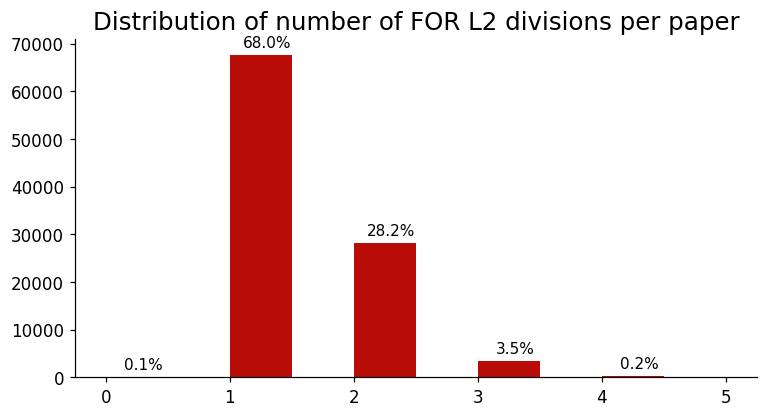

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df_ap['n_for_l2'].hist(ax=ax) 
# add annotation of percentage
for n in range(0, df_ap['n_for_l2'].max() + 1):
    count = (df_ap['n_for_l2'] == n).sum()
    pct = 100 * count / len(df_ap)
    ax.annotate(f"{pct:.1f}%", xy=(n+0.3, count), xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=STYLE["annot_fs"])
ax.grid(False)
ax.set_title("Distribution of number of FOR L2 divisions per paper", fontsize=STYLE["title_fs"])


### Per-author summary (`df_authors`)

A convenience one-row-per-author view, derived from `df_ap` (which stays the source of
truth). Two kinds of column:

* **Identity / activity** — modal name, first/last active year, paper & citation totals.
* **Home institution & country** — taken **directly from the author's
  `current_organization_id`** (their principal organisation, which we verified is
  *constant* across all of an author's papers). We resolve that grid id to an org
  name + country via a `grid_lut` lookup built from every affiliation in the corpus.
  For the **~16% of authors with no `current_organization_id`**, we fall back to the
  **modal main-affiliation** from `df_ap`. The column `home_source`
  (`current_org` / `modal_fallback`) records which path was used.

Note the distinction from `df_ap`: in `df_ap` the affiliation is resolved **per paper**
(prefer current org *if listed on that paper*, else first-listed); here in `df_authors`
we use the author's current org **directly**, independent of any single paper.

In [8]:
def _mode(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else None


def _modal_by_group(ap, key, col):
    """Fast per-group modal value (avoids a slow python lambda over every group)."""
    c = ap[[key, col]].dropna()
    cnt = c.groupby([key, col], observed=True).size().reset_index(name="_n")
    cnt = cnt.sort_values("_n").drop_duplicates(key, keep="last")  # keep max count
    return cnt.set_index(key)[col]


def build_author_summary(ap, grid_lut):
    out = ap.groupby("author_id").agg(
        n_papers=("paper_id", "nunique"),
        total_citations=("times_cited", "sum"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    # identity columns: modal across the author's papers
    for col in ["full_name", "first_name", "current_org_id"]:
        out[col] = _modal_by_group(ap, "author_id", col)
    # most frequent FOR L2 division across ALL the author's paper-division memberships
    # (frequency-based, order-independent — no reliance on a "primary" division)
    ap_l2 = ap[["author_id", "for_l2"]].explode("for_l2")
    out["modal_for_l2"] = _modal_by_group(ap_l2, "author_id", "for_l2")

    # modal main-affiliation (used only as fallback when no current org)
    m_org = _modal_by_group(ap, "author_id", "org_name").reindex(out.index)
    m_cty = _modal_by_group(ap, "author_id", "country").reindex(out.index)
    m_cc = _modal_by_group(ap, "author_id", "country_code").reindex(out.index)

    # HOME institution/country: directly from current_organization_id, else fallback
    org_name, country, country_code, source = [], [], [], []
    for gid, mo, mc, mcc in zip(out["current_org_id"], m_org, m_cty, m_cc):
        info = grid_lut.get(gid) if isinstance(gid, str) else None
        if info and info.get("org_name"):
            org_name.append(info["org_name"]); country.append(info.get("country"))
            country_code.append(info.get("country_code")); source.append("current_org")
        else:
            org_name.append(mo); country.append(mc)
            country_code.append(mcc); source.append("modal_fallback")
    out["org_name"], out["country"] = org_name, country
    out["country_code"], out["home_source"] = country_code, source
    return out.reset_index()


# grid_lut (grid id -> org name/country) is built in section 2 during affiliation
# enrichment; rebuilt here so this cell can also be run on its own.
grid_lut = build_grid_lookup(df)
df_authors = build_author_summary(df_ap, grid_lut)
print(f"Authors: {len(df_authors):,}")
print("Home institution source:")
print(df_authors["home_source"].value_counts().to_string())
df_authors.sort_values("n_papers", ascending=False)[
    ["author_id", "full_name", "n_papers", "org_name", "country", "home_source"]].head()

Authors: 39,768
Home institution source:
home_source
current_org       32953
modal_fallback     6815


,author_id,full_name,n_papers,org_name,country,home_source
24467,ur.01354253237.14,Jill P. Pell,183,University of Glasgow,United Kingdom,current_org
34172,ur.0626215040.23,Carlos Celis-Morales,154,University of Glasgow,United Kingdom,current_org
9826,ur.010663343457.34,George Davey Smith,123,MRC Integrative Epidemiology Unit,United Kingdom,current_org
7246,ur.01026114310.09,Naveed Sattar,119,University of Glasgow,United Kingdom,current_org
23930,ur.01345507322.39,Frederick K. Ho,116,University of Glasgow,United Kingdom,current_org


### Data-handling & transparency notes

How **missing** and **malformed** values are treated at each step — so counts are
reproducible and we know exactly what is dropped vs. imputed.

**Parsing (`parse_listcol`)** — cells are stringified Python lists. Already-a-list →
kept; string → `ast.literal_eval`; anything that fails to parse or is `NaN` → `[]`
(empty, never an exception). Non-dict elements inside a list are skipped.

**Papers dropped at the door.** `df_ap` is built **only** from the `authors` column.
**467 of 10,846 papers (4.3%)** have an empty/unparseable `authors` field and so
contribute **no** author rows — that is exactly why `df_ap` has 10,379 unique papers,
not 10,846. Importantly, **272 of those 467 still carry a `researchers` list and 453 a
`research_org_country_names`** value, so they *do* appear in the **org-country geography
basis** (§3) even though they are absent from every author-affiliation analysis. The
drop is heavier in recent years. This is the single biggest discrepancy to keep in mind.

**Author identity (`build_author_paper_table`)**
- *Missing `researcher_id`* (~6.6% of author slots): we **fall back to a synthetic id**
  from the normalised first+last name (`name::first|last`) so the author is kept rather
  than dropped. Only authors with **no id and no name at all** are dropped.
- *Duplicate (author, paper)* rows — caused by multi-affiliation authors listed twice —
  are collapsed with `drop_duplicates(["author_id","paper_id"])`, so counts are of
  **distinct** author–paper pairs.
- *Main affiliation* (`pick_main_affiliation`): 38% of author slots list **≥2**
  affiliations (max 26), 5% spanning **>1 country**, so "the" institution must be
  defined. We take the author's **main institutional home** = the listed affiliation
  whose grid id matches their `current_organization_id`; if that org is not on this
  paper (or none is recorded) we **fall back to the first-listed** affiliation. The
  chosen source is recorded in `aff_source` (`current_org` / `first_listed` / `none`).
  Slots with **no** affiliation (2.7%) get `org_name/country = None` (kept, excluded only
  where that field is required).
- `year` → `to_numeric` (bad → `NaN`); `times_cited` → numeric, `NaN`→0.

**Affiliation enrichment (grid backfill) — done first, before any analysis.** A grid id
uniquely identifies an institution; `org_name` / `country` / `country_code` are its
attributes. Dimensions sometimes lists an affiliation as a bare *department* string (no
grid, no country) or omits it entirely, so a per-paper row can lack a country even though
the *same* institution is fully described on other papers. `enrich_affiliations` fixes
this from the corpus-wide `grid_lut`: (1) a row that already has an `org_grid` gets any
missing attribute completed from it; (2) a row with **no** grid but a resolvable
`current_organization_id` adopts that principal org as this authorship's institution
(`org_grid` ← `current_org_id`, attributes from `grid_lut`). This resolves ~2.9k
un-gridded department strings (e.g. *"Department of Public Health and Primary Care"* →
*University of Cambridge*) to their parent institute and recovers a country for **1,665**
authorships (country-missing **3,443 → 1,778**) that would otherwise drop off the §3 map.
Touched rows are flagged `aff_enriched`, with `aff_source` set to `grid_completed` /
`current_org_backfill`. Everything downstream (map, Top institutes, `df_authors`) reads
the enriched table.

**Fields of Research (`build_paper_for_table`)** — `category_for_2020` is an **unordered
multi-label set**: each entry carries only a name + id (**no relevance score**), and the
list order matches sorted-by-code only ~47% of the time — so there is **no basis for a
single "primary" division**. We keep the **complete** sets per paper in `for_l2` / `for_l4`
(each L4's parent division is folded into `for_l2`). **~32% of papers carry ≥2 L2
divisions** (max 5). Non-numeric / odd-length codes are ignored; papers with no usable
category are bucketed as **`'Unclassified'`** (kept, never dropped).

**Geography (`to_iso3` / `build_country_counts`)** — prefer the ISO-2 `country_code`
when it is a clean 2-letter code; else match the country **name** via
`patent_utils.to_iso2` (pycountry + a fallback dict + fuzzy match — the same matcher as
the patents analysis). Author slots whose country cannot be resolved to ISO-3 are dropped
**from the map only** (not from other analyses). The Natural Earth shapefile tags France,
Norway, Kosovo, N. Cyprus & Somaliland with `ISO_A3 = '-99'`; we fall back to `adm0_a3`
so they still merge (otherwise France/Norway would silently vanish from the map). The
map metric is **author-level fractional** (`papers_frac`: each author 1/(authors on paper))
so internationally co-authored papers are *shared*, not double-counted; the whole
distinct-paper count (`papers`) is retained for the §3 org-basis reconciliation.

**Gender (`assign_gender`, two-pass)** — pass 1 `gender_guesser` (dictionary), pass 2
`nomquamgender` on the remainder (accept only if support ≥ `min_counts` and `P(female)`
past `thr`). `mostly_*` collapse to `male/female`; everything else stays `unknown`. The
share-of-female line uses only **classified** (male+female) authorships as the
denominator, so `unknown` doesn't distort the trend. `gender_source` records the pass.

**Network** — built from the same `df_ap`; self-loops removed; isolates retained.
Metrics are on the **full** graph; only the *drawing* is subsampled to top-degree nodes.

**Tricky points / caveats**
1. The `authors` column holds ~99.6k slots vs. an `authors_count` sum of ~147k — Dimensions
   **truncates very long author lists**, so massive consortia papers are under-counted.
2. Synthetic name-ids can **merge** two different people sharing a name, or **split** one
   person across name spellings — affects only the id-less ~6.6%.
3. Gender inference is culturally biased: ~42% of pass-1 `unknown` names are
   China-affiliated. Pass 2 rescues a chunk, but many romanised (pinyin) names are
   genuinely unisex and stay `unknown` — read the female-share **trend**, not its level.
4. FOR is genuinely **multi-label** (~32% of papers span ≥2 L2 divisions) with no
   documented ordering, so we do **not** pick a primary: Top institutes (§4) splits each
   paper's credit **equally across all** its L2 divisions, and `for_l2`/`for_l4` retain the
   complete lists on `df_ap` for any other analysis.

### Missing-data report (quantified)

The numbers behind the notes above, computed from the live data so they never drift
out of date. Every row is a place where records are dropped or imputed.

In [9]:
def missing_report(df, df_ap):
    """Tidy provenance/missingness table: where records drop or are imputed."""
    A = df["authors"]                       # already parsed to lists at load
    n_papers = len(df)
    empty_authors = (A.apply(len) == 0).sum()
    dropped = df[A.apply(len) == 0]
    dropped_with_researchers = dropped["researchers"].apply(
        lambda x: len(parse_listcol(x)) > 0).sum()
    dropped_with_orgcountry = dropped["research_org_country_names"].notna().sum()

    slots = len(df_ap)
    rows = [
        ("Papers — total in source",            n_papers, ""),
        ("Papers — usable (>=1 author parsed)",  df_ap["paper_id"].nunique(),
         "= unique papers in df_ap"),
        ("Papers — DROPPED (empty authors col)", int(empty_authors),
         f"{100*empty_authors/n_papers:.1f}% of papers"),
        ("   ...dropped but have researchers",   int(dropped_with_researchers),
         "kept by org-country basis, not author basis"),
        ("   ...dropped but have org-country",   int(dropped_with_orgcountry),
         "appear on the §3 org-country map"),
        ("Author-paper rows (df_ap)",            slots, "distinct (author, paper) pairs"),
        ("Unique authors",                       df_ap["author_id"].nunique(), ""),
        ("   ...id from synthetic name fallback", int(df_ap["author_id"]
            .astype(str).str.startswith("name::").sum()),
         "missing researcher_id"),
        ("Main affiliation via current_org",     int((df_ap["aff_source"]=="current_org").sum()),
         f'{100*(df_ap["aff_source"]=="current_org").mean():.1f}% of slots'),
        ("Main affiliation via first-listed",    int((df_ap["aff_source"]=="first_listed").sum()),
         "fallback (current org not on this paper)"),
        ("Author slots with NO affiliation",     int((df_ap["aff_source"]=="none").sum()),
         "no org_name / country (after enrichment)"),
        ("Affiliations enriched (grid identity)", int(df_ap.get("aff_enriched", pd.Series(False, index=df_ap.index)).sum()),
         "missing institute fields backfilled before any analysis"),
        ("   ...backfilled from current_org",     int((df_ap["aff_source"]=="current_org_backfill").sum()),
         "un-gridded dept / no affiliation -> author's principal org"),
        ("   ...completed from own grid",         int((df_ap["aff_source"]=="grid_completed").sum()),
         "row had a grid; missing attrs filled from it"),
        ("Slots missing org_name",               int(df_ap["org_name"].isna().sum()),
         "excluded from Top institutes (§4)"),
        ("Slots missing country",                int(df_ap["country"].isna().sum()),
         "excluded from author-basis map (§3)"),
        ("Papers with no FOR L2 division",       int(df_ap.drop_duplicates("paper_id")["for_l2"].apply(len).eq(0).sum()),
         "bucketed as 'Unclassified' in §4, not dropped"),
        ("Papers with >=2 FOR L2 divisions",     int(df_ap.drop_duplicates("paper_id")["n_for_l2"].ge(2).sum()),
         "credit split equally across divisions (§4)"),
    ]
    rep = pd.DataFrame(rows, columns=["stage", "n", "note"])
    return rep


# Stage-level provenance. Section-specific drops (country->ISO unresolved in §3,
# gender 'unknown' in §5) are reported in their own sections as they are computed.
missing_report(df, df_ap)

,stage,n,note
0,Papers — total in source,10846,
1,Papers — usable (>=1 author parsed),10379,= unique papers in df_ap
2,Papers — DROPPED (empty authors col),467,4.3% of papers
3,...dropped but have researchers,272,"kept by org-country basis, not author basis"
4,...dropped but have org-country,453,appear on the §3 org-country map
5,Author-paper rows (df_ap),99594,"distinct (author, paper) pairs"
6,Unique authors,39768,
7,...id from synthetic name fallback,6587,missing researcher_id
8,Main affiliation via current_org,77682,78.0% of slots
9,Main affiliation via first-listed,17421,fallback (current org not on this paper)


## 3. Geographic distribution

Where are UK Biobank authors based? We attribute each **author–paper** affiliation to a
country and convert to ISO-3 (reusing `patent_utils.to_iso2` / `iso2_to_iso3` so the
matching is consistent with the patents analysis).

An internationally co-authored paper would otherwise be **double-counted** — counted once
for every country on it — which is unfair to countries that publish more single-nation
work. So the map uses **author-level fractional counting** (`papers_frac`): each author
contributes **1 / (authors on their paper)** to their country, so each paper is *shared*
across countries and the world total ≈ the number of papers (not inflated). We keep the
whole count (`papers`) and `author_slots` for reference.

The map is **categorical** with fixed bins — `1–99 · 100–199 · 200–499 · 500–999 ·
1000–1999 · 2000+` — shaded light→dark on the ocean colormap; **no-paper countries are
grey**, and the **top-5** countries are outlined in black and labelled. (Fractional
counting reranks the leaders — e.g. China rises above the UK/US, because Chinese papers
carry a higher share of same-country co-authors.)

In [10]:
@lru_cache(maxsize=None)
def to_iso3(code, name):
    """ISO-3 from a country_code (ISO-2) when present, else from the country name.

    Cached: the same (code, name) pair recurs across ~100k author slots, but the
    fuzzy name-matcher (`patent.to_iso2`) is only run once per distinct input.
    """
    iso2 = None
    if isinstance(code, str) and len(code.strip()) == 2:
        iso2 = code.strip().upper()
    if iso2 is None:
        iso2 = patent.to_iso2(name)
    if iso2 is None:
        return None
    return patent.iso2_to_iso3(iso2)


def build_country_counts(ap):
    """Country-level counts with ISO-3 codes, ready for the world map.

    `papers_frac` is **author-level fractional**: each author contributes
    1 / (authors on their paper) to their country, so an internationally co-authored
    paper is *shared* across countries instead of being counted once for each — the
    fair measure. `papers` keeps the whole (double-counted) distinct-paper count for
    reference and for the §3 reconciliation with geography.ipynb.
    """
    tmp = ap.copy()
    tmp["iso3"] = [to_iso3(c, n) for c, n in zip(tmp["country_code"], tmp["country"])]
    tmp["w"] = 1.0 / ap.groupby("paper_id")["author_id"].transform("size")   # aligned
    tmp = tmp.dropna(subset=["iso3"])

    out = tmp.groupby("iso3").agg(
        author_slots=("author_id", "size"),
        papers=("paper_id", "nunique"),
        papers_frac=("w", "sum"),
        country=("country", _mode),
    ).reset_index()
    out["authors_per_paper"] = out["author_slots"] / out["papers"]
    out["papers_share"] = 100 * out["papers"] / ap["paper_id"].nunique()
    return out.sort_values("papers_frac", ascending=False).reset_index(drop=True)


def build_country_counts_orgbasis(df):
    """Paper counts per country from the paper-level `research_org_country_names`
    field (the same source `geography.ipynb` uses), but matched to ISO-3 with our
    robust matcher rather than a raw name->ADMIN join. Returns distinct papers per
    country (a paper counts once per country it has any research org in)."""
    s = (df[["id", "research_org_country_names"]]
         .assign(country=lambda d: d["research_org_country_names"].apply(parse_listcol))
         .explode("country").dropna(subset=["country"]))
    # resolve ISO-3 once per *distinct* country name (~150), not once per row
    iso_map = {n: to_iso3(None, n) for n in s["country"].unique()}
    s["iso3"] = s["country"].map(iso_map)
    s = s.dropna(subset=["iso3"]).drop_duplicates(["id", "iso3"])
    out = (s.groupby("iso3")
             .agg(papers_org=("id", "nunique"), country=("country", _mode))
             .reset_index()
             .sort_values("papers_org", ascending=False)
             .reset_index(drop=True))
    return out


country_df = build_country_counts(df_ap)
_iso = [to_iso3(c, n) for c, n in zip(df_ap["country_code"], df_ap["country"])]
print("Countries represented (author-affiliation basis):", len(country_df))
print(f"Author slots unresolved to ISO-3: {sum(i is None for i in _iso):,} "
      f"of {len(df_ap):,} ({100*sum(i is None for i in _iso)/len(df_ap):.1f}%) "
      f"-> dropped from this map only")
country_df.head(12)

Countries represented (author-affiliation basis): 93
Author slots unresolved to ISO-3: 1,778 of 99,594 (1.8%) -> dropped from this map only


,iso3,author_slots,papers,papers_frac,country,authors_per_paper,papers_share
0,CHN,27979,3481,3004.662365,China,8.037633,33.538877
1,GBR,22195,3646,2447.699589,United Kingdom,6.087493,35.128625
2,USA,21872,3607,2227.991465,United States,6.063765,34.752866
3,AUS,3982,949,472.719221,Australia,4.195996,9.143463
4,DEU,2583,639,256.324405,Germany,4.042254,6.156662
5,CAN,2276,543,250.406232,Canada,4.191529,5.231718
6,NLD,2173,600,245.393232,Netherlands,3.621667,5.780904
7,SWE,1764,605,222.262859,Sweden,2.915702,5.829078
8,KOR,1670,251,173.309746,South Korea,6.653386,2.418345
9,FRA,1110,331,109.604645,France,3.353474,3.189132


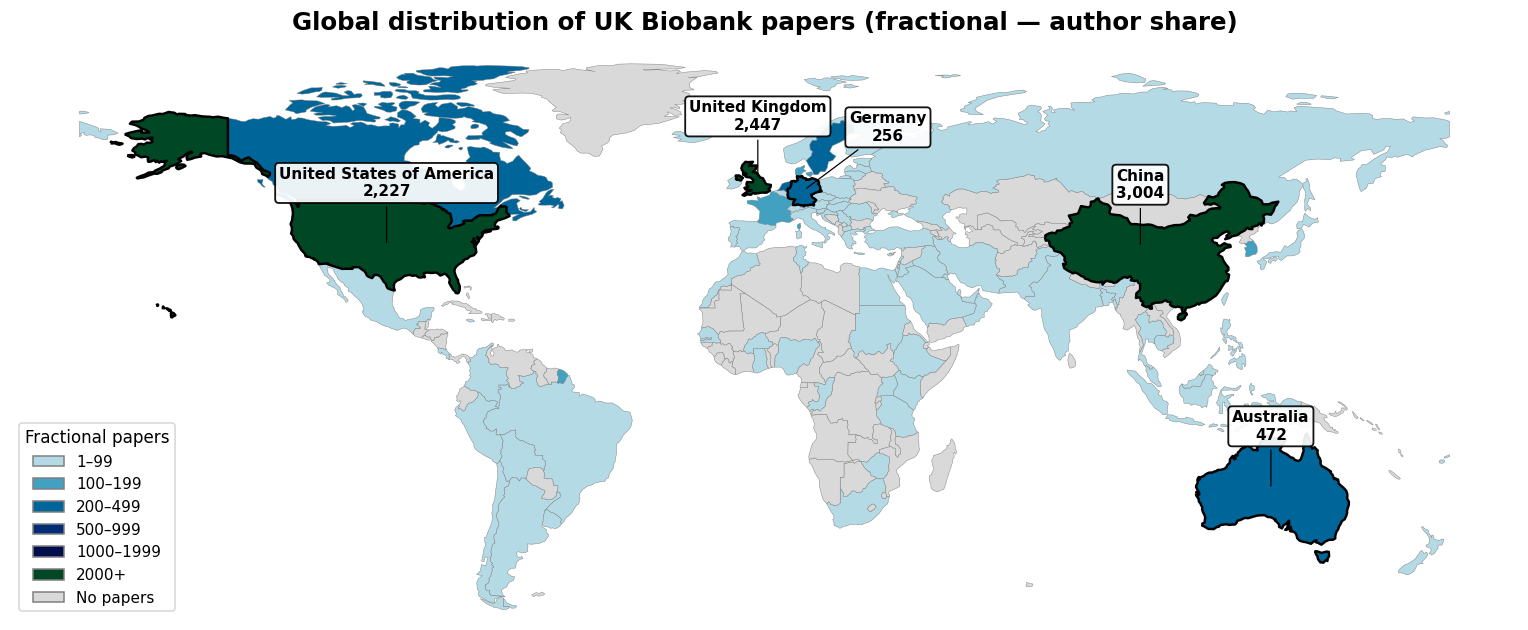

In [11]:
# Fixed bins for the papers choropleths (right-closed): 1-99, 100-199, 200-499,
# 500-999, 1000-1999, 2000+
PAPER_BINS = [0, 99, 199, 499, 999, 1999, np.inf]
PAPER_BIN_LABELS = ["1–99", "100–199", "200–499", "500–999", "1000–1999", "2000+"]


def plot_country_map(country_df, value_col="papers", style=STYLE, title=None, label=None,
                     name="geo_map", annotate_top=0, bins=None, bin_labels=None, ax=None):
    """Choropleth world map of an author-geography metric.

    bins / bin_labels: if given, values are cut into those (right-closed) categorical
        classes, coloured as discrete samples of the shared `style['cmap']` (ocean_r:
        light = few papers, dark = many); countries with no data are grey.
    annotate_top: if >0, highlight+label that many highest-`value_col` countries
        (black outline + name + value, with leader lines / a greedy stagger).
    """
    from matplotlib.patches import Patch
    from matplotlib.colors import to_rgba

    GREY = "#D9D9D9"
    world = gpd.read_file("data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
    world.columns = [c.lower() for c in world.columns]
    world = world[world["admin"] != "Antarctica"]          # drop the south-polar row
    world["iso_key"] = world["iso_a3"].where(world["iso_a3"] != "-99", world["adm0_a3"])
    merged = world.merge(country_df, how="left", left_on="iso_key", right_on="iso3")

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(1, 1, figsize=style["figsize_map"])
    else:
        fig = ax.figure

    if bins is not None:
        labels = bin_labels or [f"{int(bins[i])+1}–{int(bins[i+1])}" for i in range(len(bins) - 1)]
        k = len(labels)
        cmap_obj = plt.get_cmap(style["cmap"])
        bin_cols = [cmap_obj(t) for t in np.linspace(0.90, 0.15, k)]  # few=light, many=dark
        cats = pd.cut(merged[value_col], bins=bins, labels=labels)
        codes = cats.cat.codes.to_numpy()
        grey_rgba = to_rgba(GREY)
        col_arr = np.array([bin_cols[c] if c >= 0 else grey_rgba for c in codes])
        merged.plot(color=col_arr, ax=ax, edgecolor=style["edgecolor"], linewidth=0.3)
        handles = [Patch(facecolor=bin_cols[i], edgecolor="grey", label=labels[i])
                   for i in range(k)]
        handles.append(Patch(facecolor=GREY, edgecolor="grey", label="No papers"))
        ax.legend(handles=handles, title=label or value_col, loc="lower left",
                  frameon=True, fontsize=style["legend_fs"] - 1,
                  title_fontsize=style["legend_fs"])
    else:
        merged.plot(column=value_col, ax=ax, legend=True, cmap=style["cmap"],
                    edgecolor=style["edgecolor"], linewidth=0.3,
                    missing_kwds={"color": GREY, "label": "No data"},
                    legend_kwds={"label": label or value_col, "shrink": 0.55})

    # ---- highlight + annotate the top-N countries (black) ----
    if annotate_top:
        top = merged.dropna(subset=[value_col]).nlargest(annotate_top, value_col)
        top.boundary.plot(ax=ax, edgecolor="black", linewidth=1.6)

        placed = []
        def free_slot(x, y):
            for dy in (16, -16, 30, -30, 44, -44, 58):
                for dx in (0, 22, -22, 42, -42):
                    cx, cy = x + dx, y + dy
                    if all(abs(cx - px) > 32 or abs(cy - py) > 12 for px, py in placed):
                        return cx, cy
            return x, y + 16

        for _, row in top.sort_values(value_col, ascending=False).iterrows():
            pt = row.geometry.representative_point()
            nm = row.get("name") or row.get("admin") or row["iso3"]
            lx, ly = free_slot(pt.x, pt.y)
            placed.append((lx, ly))
            ax.annotate(
                f"{nm}\n{int(row[value_col]):,}",
                xy=(pt.x, pt.y), xytext=(lx, ly), textcoords="data",
                ha="center", va="center", fontsize=style["annot_fs"],
                fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", lw=1.2, alpha=0.92),
                arrowprops=dict(arrowstyle="-", lw=0.8, color="black"),
                zorder=6,
            )

    ax.set_ylim(-58, 90)
    ax.set_title((title if title is not None else f"Global distribution of UK Biobank authors ({value_col})"),
                 fontsize=style["title_fs"], fontweight="bold")
    ax.axis("off")
    if own_fig:
        fig.tight_layout()
        savefig(fig, name, style)
    return fig, ax


fig, ax = plot_country_map(country_df, value_col="papers_frac",
                           title="Global distribution of UK Biobank papers "
                                 "(fractional — author share)",
                           label="Fractional papers", name="geo_papers_frac",
                           annotate_top=5, bins=PAPER_BINS, bin_labels=PAPER_BIN_LABELS)
plt.show()

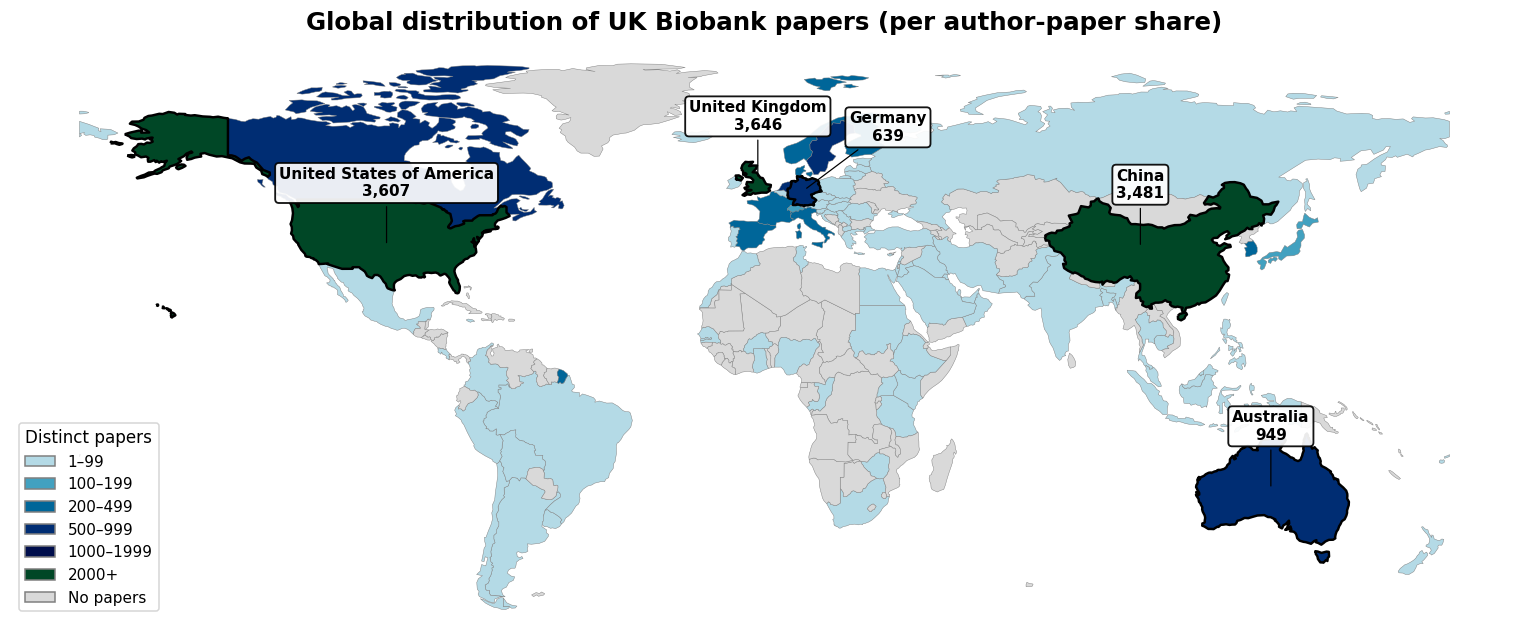

In [12]:
fig, ax = plot_country_map(country_df, value_col="papers",
                           title="Global distribution of UK Biobank papers "
                                 "(per author-paper share)",
                           label="Distinct papers", name="geo_papers",
                           annotate_top=5, bins=PAPER_BINS, bin_labels=PAPER_BIN_LABELS)
plt.show()

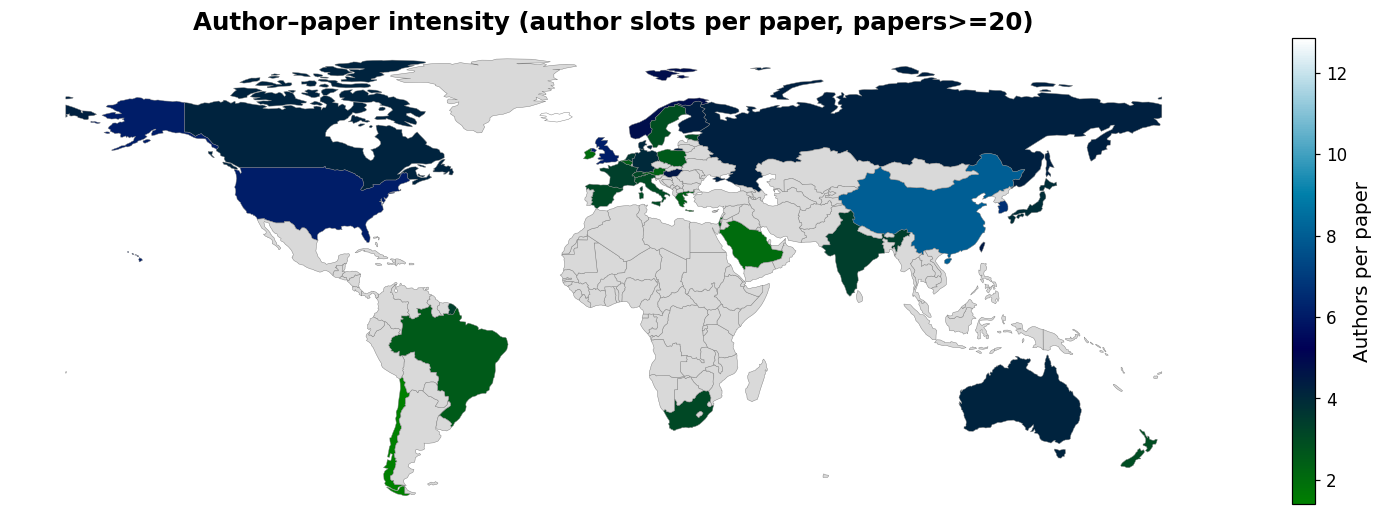

In [13]:
# Normalised view: collaboration intensity (authors per paper).
# Restrict to countries with a meaningful number of papers so the ratio is stable.
country_norm = country_df[country_df["papers"] >= 20]
fig, ax = plot_country_map(country_norm, value_col="authors_per_paper",
                           title="Author–paper intensity (author slots per paper, papers>=20)",
                           label="Authors per paper", name="geo_intensity")
plt.show()

### Cross-check with `geography.ipynb` (org-country basis)

`geography.ipynb` answers a slightly different question — *where are the research
**organisations**?* — using the paper-level `research_org_country_names` field, whereas
our `papers` column above counts *where the **authors** are affiliated*. The two will
**not** be identical:

* our author-affiliation basis is sensitive to Dimensions' **author-list truncation**
  and uses each author's **primary** affiliation only, so it runs **lower**;
* the org-country basis is paper-level and not truncated, so it matches `geography.ipynb`.

Below we reproduce the org-country basis here (`papers_org`) using the **same source
field** as `geography.ipynb` but our **robust ISO matcher** — which, unlike that
notebook's raw name→`ADMIN` join, does not silently drop Singapore (~191 papers),
Russia (~78), Serbia, Malta, etc. We show both side by side so the numbers reconcile
and the gap is transparent.

In [14]:
country_org = build_country_counts_orgbasis(df)
print("Countries represented (org-country basis):", len(country_org))

# Reconciliation table: author-affiliation vs org-country, distinct papers per country
recon = (country_df[["iso3", "country", "papers"]]
         .rename(columns={"papers": "papers_author_affil"})
         .merge(country_org[["iso3", "papers_org"]], on="iso3", how="outer"))
recon["country"] = recon["country"].fillna(
    recon["iso3"].map(country_org.set_index("iso3")["country"]))
recon = recon.sort_values("papers_org", ascending=False).reset_index(drop=True)
recon["author_vs_org_%"] = (100 * recon["papers_author_affil"]
                            / recon["papers_org"]).round(1)
print("\nTop 15 by org-country papers (author-affiliation vs org basis):")
recon.head(15)

Countries represented (org-country basis): 122

Top 15 by org-country papers (author-affiliation vs org basis):


,iso3,country,papers_author_affil,papers_org,author_vs_org_%
0,USA,United States,3607.0,4228.0,85.3
1,GBR,United Kingdom,3646.0,4205.0,86.7
2,CHN,China,3481.0,3666.0,95.0
3,AUS,Australia,949.0,1269.0,74.8
4,SWE,Sweden,605.0,955.0,63.4
5,DEU,Germany,639.0,944.0,67.7
6,NLD,Netherlands,600.0,942.0,63.7
7,CAN,Canada,543.0,722.0,75.2
8,DNK,Denmark,302.0,520.0,58.1
9,FRA,France,331.0,487.0,68.0


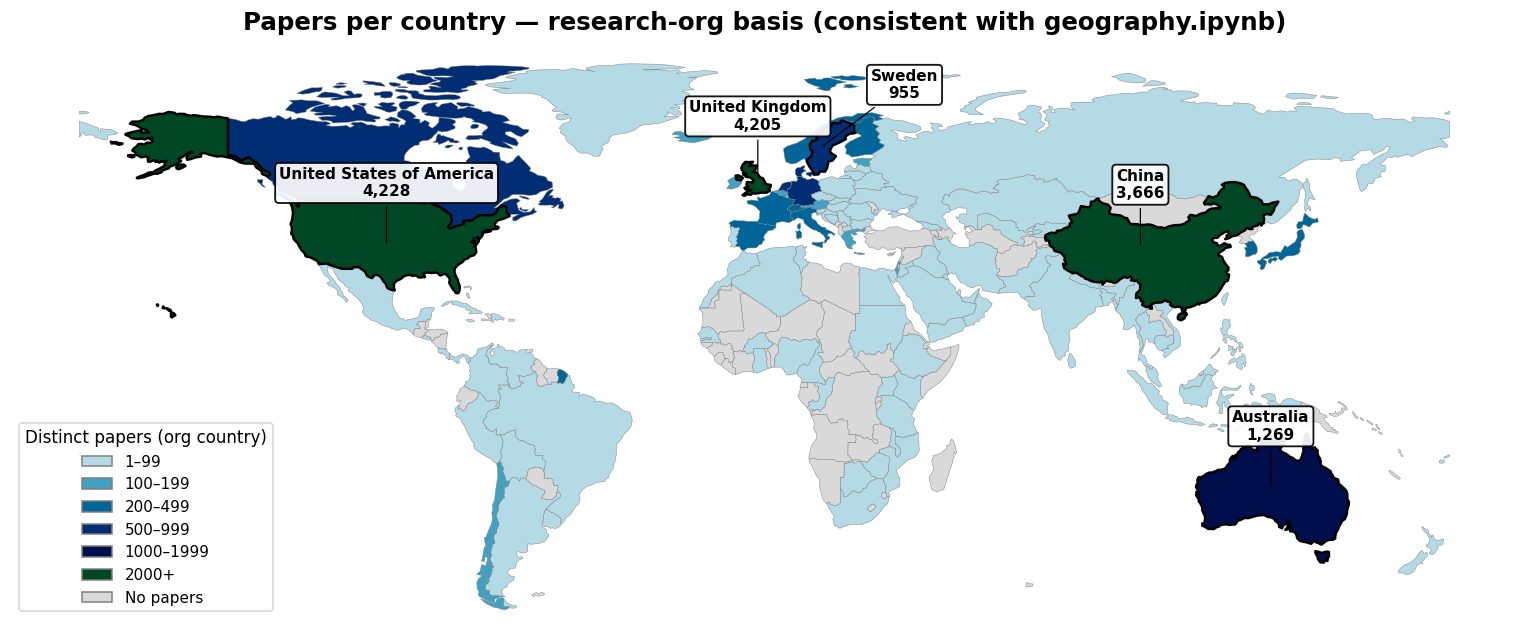

In [15]:
# Org-country choropleth — directly comparable to geography.ipynb's map,
# but matched via ISO-3 (Singapore, Russia, etc. are no longer dropped).
fig, ax = plot_country_map(country_org, value_col="papers_org",
                           title="Papers per country — research-org basis "
                                 "(consistent with geography.ipynb)",
                           label="Distinct papers (org country)", name="geo_papers_orgbasis",
                           annotate_top=5, bins=PAPER_BINS, bin_labels=PAPER_BIN_LABELS)
plt.show()

## 4. Top institutes

The most prolific institutions, using **fractional (author-level) counting**: each
author contributes **1 / (number of authors on their paper)** to their main-affiliation
institution. So a paper written across several universities gives each a *share* instead
of a full point, and an institution that supplied more of the author team earns
proportionally more credit — avoiding the whole-counting inflation where every institution
on a 50-author consortium paper would each score a full paper.

Each bar is **stacked by Field of Research (FOR L2 division)**. Because `category_for_2020`
is an unordered multi-label set (no "primary" division exists — see §2), each institution's
fractional weight for a paper is **split equally across all that paper's L2 divisions**
(papers with none → *Unclassified*), so the coloured segments sum exactly to the
institution's total. The **top `n_for` divisions** are shown, the rest folded into *Other*.

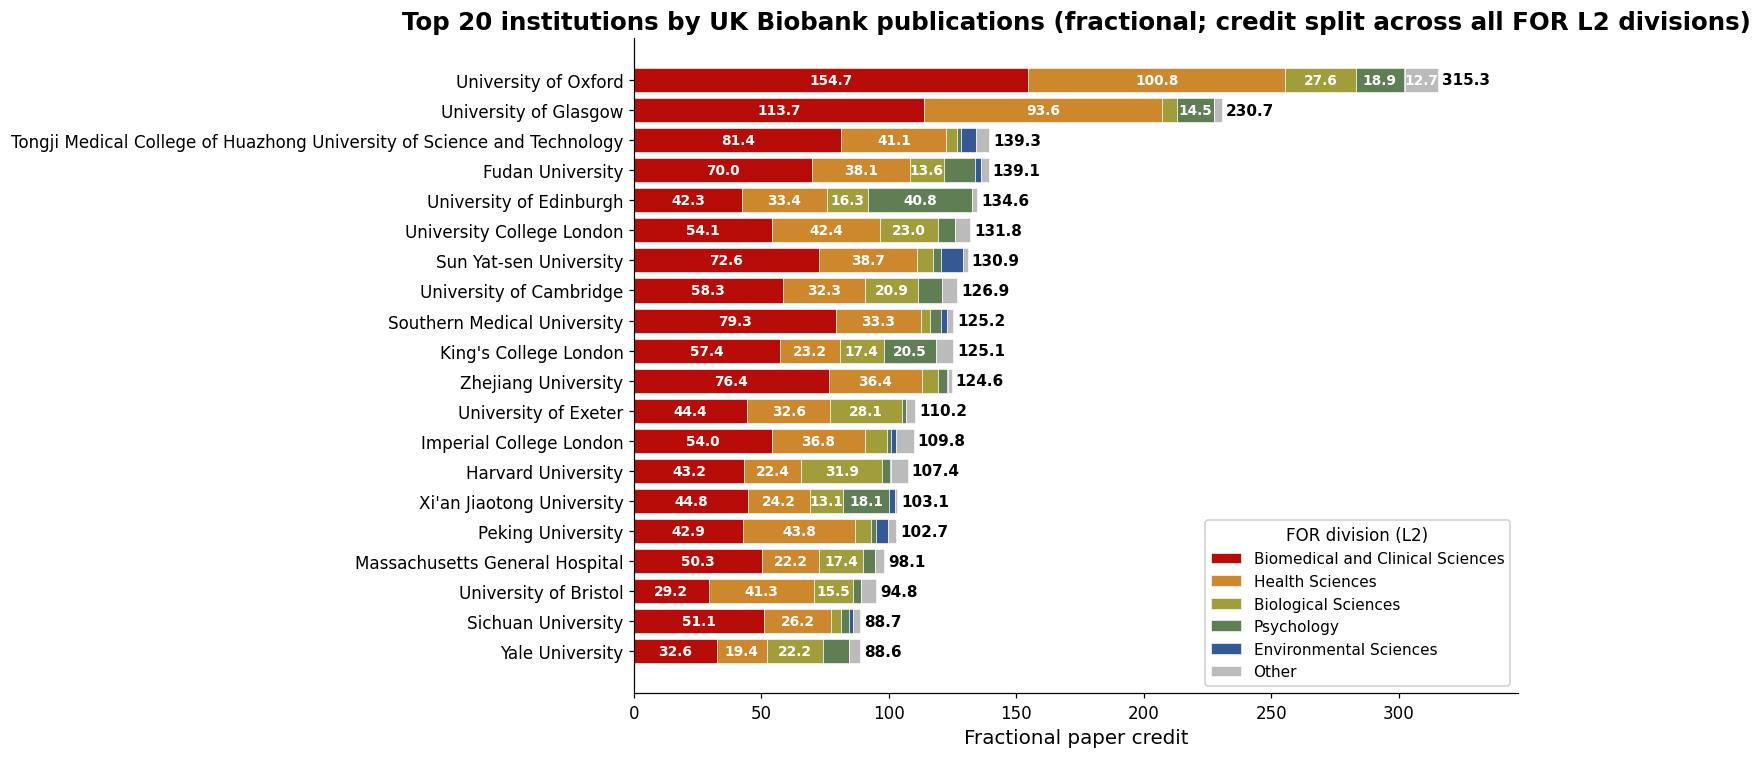

,org_name,papers,authors,country
0,University of Oxford,315.324742,754,United Kingdom
1,University of Glasgow,230.674172,259,United Kingdom
2,Tongji Medical College of Huazhong University ...,139.315877,330,China
3,Fudan University,139.117571,400,China
4,University of Edinburgh,134.626479,318,United Kingdom
5,University College London,131.792307,385,United Kingdom
6,Sun Yat-sen University,130.949153,485,China
7,University of Cambridge,126.904741,381,United Kingdom
8,Southern Medical University,125.243137,498,China
9,King's College London,125.136401,362,United Kingdom


In [16]:
def top_institutes(ap, n=10):
    """Top-n institutions (fractional) with a per-FOR-division breakdown.

    Counting: **author-level fractional** — each author contributes
    1 / (authors on their paper) to their main-affiliation institution.
    FOR: `category_for_2020` is an unordered multi-label set, so a paper is tagged with
    ALL its L2 divisions and each institution's weight for that paper is split **equally
    across those divisions** (a paper with no L2 -> 'Unclassified'). The per-division
    contributions therefore sum exactly to the institution's total.
    """
    base = ap.dropna(subset=["org_name"]).copy()
    base["w"] = 1.0 / ap.groupby("paper_id")["author_id"].transform("size").loc[base.index]

    totals = (base.groupby("org_name")
                  .agg(papers=("w", "sum"),
                       authors=("author_id", "nunique"),
                       country=("country", _mode))
                  .reset_index().sort_values("papers", ascending=False)
                  .head(n).reset_index(drop=True))

    sub = base[base["org_name"].isin(totals["org_name"])].copy()
    sub["divs"] = sub["for_l2"].apply(lambda L: L if isinstance(L, list) and len(L) else ["Unclassified"])
    sub["k"] = sub["divs"].apply(len)
    sub = sub.explode("divs")
    sub["wl2"] = sub["w"] / sub["k"]
    breakdown = (sub.groupby(["org_name", "divs"])["wl2"].sum()
                 .reset_index().rename(columns={"divs": "division", "wl2": "papers"}))
    return totals, breakdown


def plot_top_institutes(totals, breakdown, n_for=6, style=STYLE,
                        name="top_institutes", value_label="Fractional paper credit",
                        title=None, ax=None, normalize=False):
    order = totals.sort_values("papers")["org_name"].tolist()   # small->large (barh)

    top_divs = (breakdown.groupby("division")["papers"].sum()
                .sort_values(ascending=False).head(n_for).index.tolist())
    bk = breakdown.copy()
    bk["div"] = bk["division"].where(bk["division"].isin(top_divs), "Other")
    mat = (bk.groupby(["org_name", "div"])["papers"].sum()
             .unstack(fill_value=0).reindex(order))
    cols = [d for d in top_divs if d in mat.columns] + (["Other"] if "Other" in mat.columns else [])
    mat = mat[cols]

    # normalize=True -> segment ANNOTATIONS show each division as a % of the institution's
    # own total; the bar WIDTHS stay ABSOLUTE, so cross-institution size differences remain.
    row_total = mat.sum(axis=1)

    pal = extended_palette(len(top_divs), style)
    cmap = {d: pal[i] for i, d in enumerate(top_divs)}
    cmap["Other"] = "#BBBBBB"

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=style["figsize_wide"])
    else:
        fig = ax.figure
    left = np.zeros(len(mat))
    seg_thresh = totals["papers"].max() * 0.04   # only label segments wide enough
    for d in cols:
        vals = mat[d].values
        ax.barh(mat.index, vals, left=left, color=cmap[d],
                edgecolor="white", linewidth=0.4, label=d)
        for y, (v, x0, org) in enumerate(zip(vals, left, mat.index)):
            if v >= seg_thresh:
                lab = f"{100 * v / row_total[org]:.0f}%" if normalize else f"{v:.1f}"
                ax.text(x0 + v / 2, y, lab, va="center", ha="center",
                        fontsize=style["annot_fs"] - 1, color="white", fontweight="bold")
        left += vals
    totmap = totals.set_index("org_name")["papers"]
    for y, org in enumerate(mat.index):
        ax.text(totmap[org] + totmap.max() * 0.005, y, f"{totmap[org]:,.1f}",
                va="center", fontsize=style["annot_fs"], fontweight="bold")
    ax.set_xlabel(value_label)
    ax.set_title(title or (f"Top {len(mat)} institutions by UK Biobank publications "
                           f"(fractional; credit split across all FOR L2 divisions)"),
                 fontsize=style["title_fs"], fontweight="bold")
    ax.margins(x=0.10)
    ax.legend(title="FOR division (L2)", fontsize=style["legend_fs"] - 1,
              title_fontsize=style["legend_fs"], loc="lower right", framealpha=0.95)
    if own_fig:
        fig.tight_layout()
        savefig(fig, name, style)
    return fig, ax


inst_totals, inst_breakdown = top_institutes(df_ap, n=20)
fig, ax = plot_top_institutes(inst_totals, inst_breakdown, n_for=5)
plt.show()
inst_totals

## 5. Gender trends over time

We infer author gender from first names with a **two-pass, fully offline** approach
(no network calls):

1. **`gender_guesser`** — a curated dictionary, strong on Western names.
2. **`nomquamgender`** (fallback for pass-1 `unknown`) — a much larger name→gender
   model built from ~100M+ tagged records. It gives each name a `P(female)` plus a
   support count; we accept a call only when the name has **≥ `min_counts`** observations
   and `P(female)` is **≥ `thr`** (female) or **≤ 1−`thr`** (male), leaving genuinely
   unisex names as `unknown`.

This matters here because **~43% of names were `unknown` after pass 1, and ~42% of those
are China-affiliated** (plus Korea/Taiwan/Singapore) — romanised East-Asian given names
that `gender_guesser` simply doesn't list. Pass 2 rescues a meaningful share of them
(e.g. *Xiaoyan*→F, *Jing*/*Hui*→F, *Wei*/*Ming*/*Yan*→M) while correctly abstaining on
truly ambiguous ones (*Zhuo*, *Lei*, *Hong*). The column `gender_source`
(`gender_guesser` / `nomquamgender` / `unknown`) records which pass decided each author.

Gender is assigned **once per author** (on their modal first name) and propagated to the
author–paper table, so each authorship inherits a gender. We then track the
**share of female authorships per year**.

> *Caveat:* even after refinement, many East-Asian names remain `unknown` because their
> romanised (pinyin) form is genuinely unisex — the character that carries the gender is
> lost. Treat the female-share **trend** as indicative, not its absolute level, and note
> that unknown coverage is uneven across countries.

In [17]:
_DET = gender_detector.Detector(case_sensitive=False)
_NQG = nqg.NBGC()   # loads the offline name-gender table once


def infer_gender(first_name):
    """Pass 1 — gender_guesser dictionary lookup on the first token of the name."""
    if not isinstance(first_name, str) or not first_name.strip():
        return "unknown"
    g = _DET.get_gender(first_name.strip().split()[0])
    if g in ("male", "mostly_male"):
        return "male"
    if g in ("female", "mostly_female"):
        return "female"
    return "unknown"


def assign_gender(first_names, thr=0.80, min_counts=30):
    """Two-pass gender per *unique* first name. Returns (gender_map, source_map).

    Pass 1: gender_guesser. Pass 2 (only for pass-1 'unknown'): nomquamgender, accepting
    a call when the name has >= min_counts support and P(female) >= thr / <= 1-thr.
    """
    uniq = [n for n in pd.unique(pd.Series(list(first_names)))
            if isinstance(n, str) and n.strip()]
    gender = {n: infer_gender(n) for n in uniq}
    source = {n: ("gender_guesser" if gender[n] != "unknown" else "unknown") for n in uniq}

    unknown = [n for n in uniq if gender[n] == "unknown"]
    if unknown:
        # columns: [name given, string used, #sources, #counts, p(female)]
        ann = _NQG.annotate(unknown, as_df=True).to_numpy()
        for nm, row in zip(unknown, ann):
            counts, p_gf = row[3], row[4]
            if counts >= min_counts and not pd.isna(p_gf):
                if p_gf >= thr:
                    gender[nm], source[nm] = "female", "nomquamgender"
                elif p_gf <= 1 - thr:
                    gender[nm], source[nm] = "male", "nomquamgender"
    return gender, source


# assign gender per author (two-pass), then propagate to the author-paper table
gender_map, source_map = assign_gender(df_authors["first_name"])
df_authors["gender"] = df_authors["first_name"].map(gender_map).fillna("unknown")
df_authors["gender_source"] = df_authors["first_name"].map(source_map).fillna("unknown")

df_ap = df_ap.drop(columns=[c for c in ("gender",) if c in df_ap.columns])
df_ap = df_ap.merge(df_authors[["author_id", "gender"]], on="author_id", how="left")

print("Gender distribution (authors):")
print(df_authors["gender"].value_counts(normalize=True).round(3).to_string())
print("\nDecided by (source):")
print(df_authors["gender_source"].value_counts().to_string())
rescued = int((df_authors["gender_source"] == "nomquamgender").sum())
unk_before = int((df_authors["first_name"].apply(infer_gender) == "unknown").sum())
print(f"\nPass-2 (nomquamgender) rescued {rescued:,} of {unk_before:,} pass-1 'unknown' "
      f"authors ({100*rescued/max(unk_before,1):.1f}%)")

Gender distribution (authors):
gender
male       0.386
unknown    0.337
female     0.277

Decided by (source):
gender_source
gender_guesser    22674
unknown           13414
nomquamgender      3680

Pass-2 (nomquamgender) rescued 3,680 of 17,094 pass-1 'unknown' authors (21.5%)


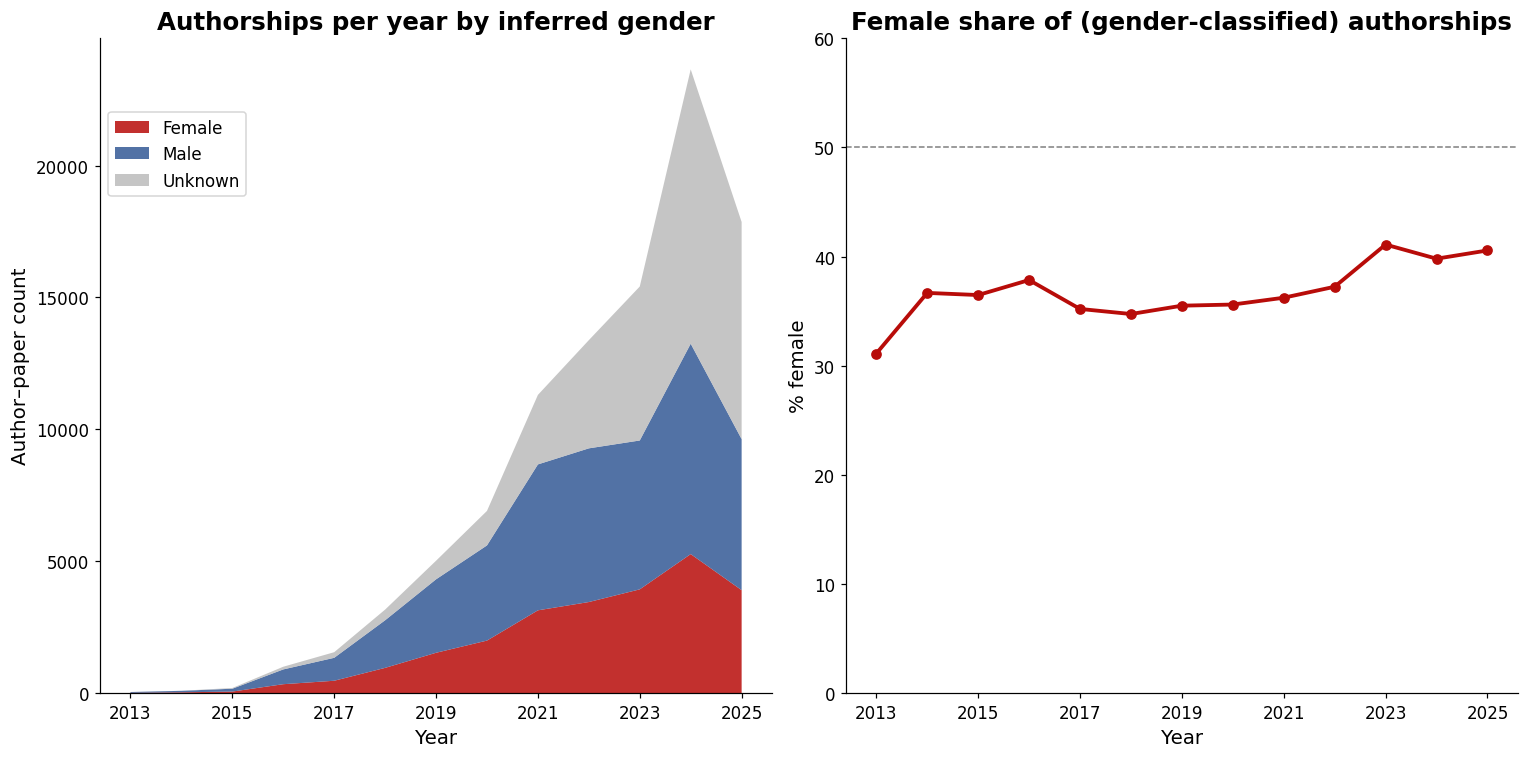

gender,female,male,unknown,female_share
year,,,,
2013,14,31,0,31.1
2014,33,57,2,36.7
2015,62,108,27,36.5
2016,341,560,102,37.8
2017,472,869,213,35.2
2018,960,1804,405,34.7
2019,1532,2784,704,35.5
2020,1994,3607,1308,35.6
2021,3141,5530,2635,36.2


In [18]:
def gender_over_time(ap, min_year=None, max_year=None):
    """Yearly authorship counts and female share among gender-classified authorships."""
    d = ap.dropna(subset=["year"]).copy()
    d["year"] = d["year"].astype(int)
    if min_year: d = d[d["year"] >= min_year]
    if max_year: d = d[d["year"] <= max_year]
    tab = d.pivot_table(index="year", columns="gender", values="paper_id",
                        aggfunc="count", fill_value=0)
    for c in ("female", "male", "unknown"):
        if c not in tab: tab[c] = 0
    tab["known"] = tab["female"] + tab["male"]
    tab["female_share"] = 100 * tab["female"] / tab["known"].replace(0, np.nan)
    return tab


def plot_gender_trends(tab, style=STYLE, name="gender_trends", axes=None):
    own_fig = axes is None
    if own_fig:
        fig, axes = plt.subplots(1, 2, figsize=style["figsize_wide"])
    else:
        fig = axes[0].figure

    # (a) stacked authorship volume by gender
    ax = axes[0]
    ax.stackplot(tab.index, tab["female"], tab["male"], tab["unknown"],
                 labels=["Female", "Male", "Unknown"],
                 colors=[style["gender_colors"]["female"],
                         style["gender_colors"]["male"],
                         style["gender_colors"]["unknown"]], alpha=0.85)
    ax.set_title("Authorships per year by inferred gender",
                 fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Author–paper count")
    ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.90))

    # (b) female share among classified authorships
    ax = axes[1]
    ax.plot(tab.index, tab["female_share"], marker="o",
            color=style["c_accent"], linewidth=2.5)
    ax.axhline(50, ls="--", color="grey", linewidth=1)
    ax.set_title("Female share of (gender-classified) authorships",
                 fontsize=style["title_fs"], fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("% female")
    ax.set_ylim(0, max(60, tab["female_share"].max() + 5))
    for _a in axes:                     # integer year ticks (every 2 yrs to avoid crowding)
        _a.set_xticks(range(int(tab.index.min()), int(tab.index.max()) + 1, 2))
    if own_fig:
        fig.tight_layout()
        savefig(fig, name, style)
    return fig, axes


gtab = gender_over_time(df_ap, min_year=2013)
fig, axes = plot_gender_trends(gtab)
plt.show()
gtab[["female", "male", "unknown", "female_share"]].round(1)

## 6. Network collaboration — co-authorship communities (Leiden)

A co-authorship network where nodes are authors and an edge links two authors who appear
on the same paper. We build the sparse bipartite author×paper matrix `AP` and project it
to the weighted author–author network `AA = AP·APᵀ` (edge weight = shared papers), exactly
as in `01_analysis_02_network_over_time.ipynb` — but **entirely from this notebook's own
`df_ap`** (the enriched *authors*-column basis), so nothing here depends on that notebook.

The **main plot** is the **community-aggregated network**: we run **Leiden**
(`leidenalg`, `RBConfigurationVertexPartition`, resolution 1.0, weighted) on the full
final-snapshot author graph, then collapse it to the **10 largest communities** plus an
aggregate *Other Communities* node. Each community node is sized by its number of authors
and edges are weighted by inter-community collaborations; communities are labelled by the
FOR-L4 research topics and the institutions of their members (each shown up to ~50% author
coverage). Four **cumulative growth panels** (authors, collaborations, mean degree,
giant-component size) sit alongside on the same `df_ap` basis.

> **Basis note (why the numbers differ from `01_analysis_02_network_over_time.ipynb`).**
> That notebook builds its graph from the **`researchers`** field; here everything is built
> from the **`authors`** field via `df_ap`. The two identity bases give different node and
> edge counts — e.g. **mean degree ≈ 24.8 here vs ≈ 29.0 there** — because `df_ap` keeps the
> ~6.6k id-less authors under synthetic name-ids (extra, mostly low-degree nodes) while
> `researchers` keeps only Dimensions-disambiguated researchers on a slightly larger set of
> papers (it includes the 272 researcher-only papers that have no parseable `authors`). Same
> formula (mean unweighted degree over all nodes), different underlying data.

In [19]:
from scipy.sparse.csgraph import connected_components
import math
import textwrap
import matplotlib.patheffects as pe

try:
    import igraph as ig
    import leidenalg
except ImportError as exc:                      # pragma: no cover
    raise ImportError(
        "The community analysis needs python-igraph and leidenalg. Install them in the "
        "ukbb20 env with:  conda install -n ukbb20 -c conda-forge python-igraph leidenalg"
    ) from exc


def build_coauthor_matrix(ap):
    """Sparse author-author co-authorship matrix AA = AP·APᵀ (edge weight = shared
    papers), plus the author-id array indexing its rows/cols. Pure scipy — building
    a 40k-node networkx graph is avoided; metrics come straight from the matrix."""
    authors = ap["author_id"].unique()
    papers = ap["paper_id"].unique()
    a2i = {a: i for i, a in enumerate(authors)}
    p2i = {p: i for i, p in enumerate(papers)}
    r = ap["author_id"].map(a2i).to_numpy()
    c = ap["paper_id"].map(p2i).to_numpy()
    AP = sp.csr_matrix((np.ones(len(r)), (r, c)), shape=(len(authors), len(papers)))
    AA = (AP @ AP.T).tocsr()
    AA.setdiag(0)
    AA.eliminate_zeros()                 # drop self-loops
    return AA, authors


def network_summary(AA):
    """Headline metrics computed directly from the sparse adjacency (fast)."""
    n = AA.shape[0]
    adj = AA > 0
    deg = np.asarray(adj.sum(axis=1)).ravel()
    n_edges = int(adj.nnz // 2)
    ncomp, labels = connected_components(adj, directed=False)
    giant = int(np.bincount(labels).max()) if n else 0
    return {
        "n_nodes": n,
        "n_edges": n_edges,
        "n_components": int(ncomp),
        "giant_nodes": giant,
        "giant_frac": giant / n if n else 0,
        "avg_degree": float(deg.mean()) if n else 0,
        "density": (2 * n_edges / (n * (n - 1)) if n > 1 else 0),
    }


def network_metrics_over_time(ap, min_year=None, max_year=None):
    """Cumulative co-authorship metrics, one row per year (for the side panels)."""
    d = ap.dropna(subset=["year"]).copy()
    d["year"] = d["year"].astype(int)
    y0 = int(min_year or d["year"].min())
    y1 = int(max_year or d["year"].max())
    recs = []
    for y in range(y0, y1 + 1):
        sub = d[d["year"] <= y]
        AA, _ = build_coauthor_matrix(sub)
        s = network_summary(AA)
        s["year"] = y
        s["n_papers"] = sub["paper_id"].nunique()
        recs.append(s)
    return pd.DataFrame(recs).set_index("year")


# Full final network: matrix + headline metrics (sparse, ~1s)
AA, net_authors = build_coauthor_matrix(df_ap)
summary = network_summary(AA)
for k, v in summary.items():
    print(f"{k:>14}: {v:,.4f}" if isinstance(v, float) else f"{k:>14}: {v:,}")

# Weighted author graph (networkx) used for Leiden community detection; integer nodes
# map back to author ids via net_authors[i]. Edge 'weight' = number of shared papers.
G_auth = nx.from_scipy_sparse_array(AA)

# Cumulative metrics for the four growth panels (same df_ap basis as the network above)
metrics_ot = network_metrics_over_time(df_ap, min_year=2013)
metrics_ot[["n_nodes", "n_edges", "avg_degree", "giant_nodes"]]


       n_nodes: 39,768
       n_edges: 492,886
  n_components: 540
   giant_nodes: 35,614
    giant_frac: 0.8955
    avg_degree: 24.7881
       density: 0.0006


,n_nodes,n_edges,avg_degree,giant_nodes
year,,,,
2013,31,132,8.516129,14
2014,63,273,8.666667,19
2015,186,1399,15.043011,41
2016,702,8924,25.424501,553
2017,1545,26233,33.958576,1337
2018,3054,48167,31.543549,2757
2019,5110,82727,32.378474,4599
2020,8129,116356,28.627383,7154
2021,12513,178954,28.602893,11269


In [20]:
# =============================================================================
# LEIDEN COMMUNITY DETECTION + COMMUNITY-AGGREGATED NETWORK
# -----------------------------------------------------------------------------
# Ported from 01_analysis_02_network_over_time.ipynb so this notebook is fully
# self-contained. The algorithm/collapse/label/plot code is copied over; only the
# graph is built from THIS notebook's df_ap (authors basis) and the per-author
# topic/institution metadata comes from df_ap's own for_l4 / for_l2 / org_name.
# =============================================================================
import re

TOPIC_LABEL_OVERRIDES = {
    "Biomedical and Clinical Sciences": "Biomedical/Clinical",
    "Biological Sciences": "Biological",
    "Health Sciences": "Health",
    "Information and Computing Sciences": "Computing",
    "Chemical Sciences": "Chemistry",
    "Environmental Sciences": "Environmental",
    "Cardiovascular Medicine and Haematology": "Cardio/Haem",
    "Oncology and Carcinogenesis": "Oncology",
    "Health Services and Systems": "Health Services",
    "Ophthalmology and Optometry": "Ophthalmology",
    "Pharmacology and Pharmaceutical Sciences": "Pharmacology",
    "Medical Biochemistry and Metabolomics": "Medical Biochemistry",
    "Bioinformatics and Computational Biology": "Bioinformatics",
    "Clinical and Health Psychology": "Clinical Psychology",
    "Cognitive and Computational Psychology": "Cognitive Psychology",
}
INSTITUTION_LABEL_OVERRIDES = {
    "University of Pennsylvania": "UPenn", "Broad Institute": "Broad",
    "University of North Carolina at Chapel Hill": "UNC Chapel Hill",
    "Massachusetts General Hospital": "MGH",
    "Vanderbilt University Medical Center": "Vanderbilt",
    "University of Oxford": "Oxford", "University of Cambridge": "Cambridge",
    "University College London": "UCL", "Imperial College London": "Imperial",
    "Queen Mary University of London": "Queen Mary",
    "King's College London": "KCL",
    "University of Edinburgh": "Edinburgh", "University of Bristol": "Bristol",
    "University of Exeter": "Exeter", "Stanford University": "Stanford",
    "Harvard University": "Harvard", "University of Queensland": "Queensland",
    "Brigham and Womens Hospital Inc": "Brigham & Women's",
    "Regeneron Pharmaceuticals Inc": "Regeneron",
    "Icahn School of Medicine at Mount Sinai": "Mount Sinai",
    "Queen's University Belfast": "Queen's Belfast",
}


# ---- Leiden detection & aggregation -----------------------------------------
def networkx_to_igraph(graph, weight_attr="weight"):
    """Convert an undirected weighted networkx graph to igraph, preserving nodes."""
    nodes = list(graph.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    edges = [(node_to_idx[u], node_to_idx[v]) for u, v in graph.edges()]
    weights = [float(d.get(weight_attr, 1.0)) for _, _, d in graph.edges(data=True)]
    ig_graph = ig.Graph(n=len(nodes), edges=edges, directed=False)
    ig_graph.vs["nx_node"] = nodes
    if weights:
        ig_graph.es["weight"] = weights
    return ig_graph, nodes


def detect_leiden_communities(graph, resolution=1.0, seed=48652, weight_attr="weight"):
    """Run Leiden (RBConfigurationVertexPartition, weighted) on the full author graph.
    Returns {nx_node: community_id} and the weighted modularity of the partition."""
    ig_graph, nx_nodes = networkx_to_igraph(graph, weight_attr=weight_attr)
    weights = "weight" if ig_graph.ecount() > 0 else None
    partition = leidenalg.find_partition(
        ig_graph, leidenalg.RBConfigurationVertexPartition,
        weights=weights, resolution_parameter=resolution, n_iterations=-1, seed=seed)
    membership_by_node = dict(zip(nx_nodes, partition.membership))
    modularity_weights = ig_graph.es["weight"] if ig_graph.ecount() > 0 else None
    modularity = ig_graph.modularity(partition.membership, weights=modularity_weights)
    return membership_by_node, modularity


def build_full_community_graph(author_graph, membership_by_node, weight_attr="weight"):
    """Aggregate the author graph to the full community graph: nodes = communities
    (size = #authors), edge weight = total inter-community co-authorship collaborations."""
    community_sizes = Counter(membership_by_node.values())
    cg = nx.Graph()
    for cid, size in community_sizes.items():
        cg.add_node(int(cid), size=int(size), internal_weight=0.0)
    for u, v, data in author_graph.edges(data=True):
        cu, cv = int(membership_by_node[u]), int(membership_by_node[v])
        w = float(data.get(weight_attr, 1.0))
        if cu == cv:
            cg.nodes[cu]["internal_weight"] += w
            continue
        if cg.has_edge(cu, cv):
            cg[cu][cv]["weight"] += w
        else:
            cg.add_edge(cu, cv, weight=w)
    return cg


def collapse_community_graph(full_cg, n_largest=10, other_label="Other Communities",
                             omit_smaller_than=None):
    """Keep the n_largest communities as display nodes, merge the rest into one
    Other node. Returns (plot_graph, community_summary, community->plot_node map)."""
    size_series = pd.Series(nx.get_node_attributes(full_cg, "size"),
                            name="n_authors").sort_values(ascending=False)
    rank_by = {int(c): r for r, c in enumerate(size_series.index.tolist(), start=1)}
    kept = set(int(c) for c in size_series.head(n_largest).index)
    to_plot = {}
    for cid, size in size_series.items():
        cid = int(cid)
        if omit_smaller_than is not None and size < omit_smaller_than:
            to_plot[cid] = None
        elif cid in kept:
            to_plot[cid] = f"Community {rank_by[cid]}"
        else:
            to_plot[cid] = other_label
    pg = nx.Graph()
    for cid, size in size_series.items():
        cid = int(cid)
        pn = to_plot[cid]
        if pn is None:
            continue
        if pn not in pg:
            is_other = pn == other_label
            pg.add_node(pn, size=0, display_label=other_label if is_other else pn,
                        rank=None if is_other else rank_by[cid], is_other=is_other,
                        n_leiden_communities=0, original_communities=[],
                        internal_weight=0.0, internal_merged_weight=0.0)
        nd = pg.nodes[pn]
        nd["size"] += int(size)
        nd["n_leiden_communities"] += 1
        nd["original_communities"].append(cid)
        nd["internal_weight"] += float(full_cg.nodes[cid].get("internal_weight", 0.0))
    for cu, cv, data in full_cg.edges(data=True):
        pu, pv = to_plot[int(cu)], to_plot[int(cv)]
        if pu is None or pv is None:
            continue
        w = float(data.get("weight", 1.0))
        if pu == pv:
            pg.nodes[pu]["internal_merged_weight"] += w
            continue
        if pg.has_edge(pu, pv):
            pg[pu][pv]["weight"] += w
        else:
            pg.add_edge(pu, pv, weight=w)
    summary = pd.DataFrame({
        "leiden_community": [int(c) for c in size_series.index],
        "rank": [rank_by[int(c)] for c in size_series.index],
        "n_authors": [int(size_series.loc[c]) for c in size_series.index],
        "plot_node": [to_plot[int(c)] for c in size_series.index]})
    return pg, summary, to_plot


# ---- Community labelling: top-N topics/institutions, each with its own share ---
def make_topic_summary_by_group(df, group_col, topic_col, top_n=5):
    """Per-group ranked topic-share counts (author-weighted); topic_rank / topic_share."""
    base = df[[group_col, "author_id", topic_col]].copy()
    base[topic_col] = base[topic_col].fillna("Unclassified")
    counts = base.groupby([group_col, topic_col])["author_id"].nunique().reset_index(name="n_authors")
    totals = base.groupby(group_col)["author_id"].nunique().rename("group_authors")
    counts = counts.merge(totals, on=group_col, how="left")
    counts["topic_share"] = counts["n_authors"] / counts["group_authors"]
    counts["is_unclassified"] = counts[topic_col].eq("Unclassified")
    counts = counts.sort_values([group_col, "n_authors", "is_unclassified", topic_col],
                                ascending=[True, False, True, True])
    counts["topic_rank"] = counts.groupby(group_col).cumcount() + 1
    return counts.drop(columns="is_unclassified")


def make_institution_summary_by_group(df, group_col, institution_col="modal_institution", top_n=5):
    """Per-group ranked institution-share counts (author-weighted)."""
    base = df[[group_col, "author_id", institution_col]].copy()
    base[institution_col] = base[institution_col].fillna("Unknown institution")
    counts = base.groupby([group_col, institution_col])["author_id"].nunique().reset_index(name="n_authors")
    totals = base.groupby(group_col)["author_id"].nunique().rename("group_authors")
    counts = counts.merge(totals, on=group_col, how="left")
    counts["institution_share"] = counts["n_authors"] / counts["group_authors"]
    counts["is_unknown"] = counts[institution_col].eq("Unknown institution")
    counts = counts.sort_values([group_col, "is_unknown", "n_authors", institution_col],
                                ascending=[True, True, False, True])
    counts["institution_rank"] = counts.groupby(group_col).cumcount() + 1
    return counts.drop(columns="is_unknown")


def _short_topic_label(topic, width=24):
    if not isinstance(topic, str) or not topic.strip():
        return "Unclassified"
    label = TOPIC_LABEL_OVERRIDES.get(topic.strip(), topic.strip())
    if len(label) > width and " " not in label:
        return label[:max(width - 1, 1)] + "…"
    return textwrap.shorten(label, width=width, placeholder="…")


def _short_institution_label(inst, width=18):
    if not isinstance(inst, str) or not inst.strip():
        return "Unknown"
    s = inst.strip()
    if s in INSTITUTION_LABEL_OVERRIDES:
        return INSTITUTION_LABEL_OVERRIDES[s]
    s = re.sub(r"^The ", "", s)
    m = re.match(r"University of (.+)", s)          # "University of Oslo" -> "Oslo"
    if m:
        s = m.group(1)
    s = s.replace(" University", "").replace("University ", "")
    s = s.replace("Institute", "Inst").replace(" Inc", "")
    return textwrap.shorten(s, width=width, placeholder="…")


def _top_share_label(counts, value_col, share_col, rank_col, shortener, n=3, skip_value=None):
    """'A (30%); B (18%); C (12%)' for the top-n items by rank (each its own share)."""
    if counts is None or len(counts) == 0:
        return "n/a"
    rows = counts.sort_values(rank_col)
    if skip_value is not None:
        filtered = rows[rows[value_col].ne(skip_value)]
        if not filtered.empty:
            rows = filtered
    rows = rows.head(n)
    return "; ".join(f"{shortener(v)} ({100 * s:.0f}%)"
                     for v, s in zip(rows[value_col], rows[share_col]))


def apply_community_labels(plot_graph, topic_counts, inst_counts, other_label,
                           topic_col="modal_primary_for_l4", n_topics=3, n_inst=3,
                           wrap_width=32):
    """Two-line community label: line 1 = top-`n_topics` FOR topics (each with its own
    author share), line 2 = top-`n_inst` institutions (abbreviated, each with its share).
    Lines are wrapped to `wrap_width` so no row is too long. The Other node keeps its plain
    label."""
    tcl = ({int(c): r.copy() for c, r in topic_counts.groupby("leiden_community")}
           if topic_counts is not None else {})
    icl = ({int(c): r.copy() for c, r in inst_counts.groupby("leiden_community")}
           if inst_counts is not None else {})
    for node, data in plot_graph.nodes(data=True):
        if data.get("is_other"):
            data["display_label"] = other_label
            continue
        cid = int(data["original_communities"][0])
        topics = _top_share_label(tcl.get(cid), topic_col, "topic_share", "topic_rank",
                                  _short_topic_label, n=n_topics, skip_value="Unclassified")
        insts = _top_share_label(icl.get(cid), "modal_institution", "institution_share",
                                 "institution_rank", _short_institution_label,
                                 n=n_inst, skip_value="Unknown institution")
        line1 = textwrap.fill(f"Topics:\n {topics}", width=wrap_width)
        line2 = textwrap.fill(f"Institutions:\n {insts}", width=wrap_width)
        data["display_label"] = f"{line1}\n{line2}"
    return plot_graph


# ---- Layout / drawing helpers -----------------------------------------------
def make_value_scaler(values, out_min, out_max, transform=None):
    """Callable mapping data values into [out_min, out_max] (optional transform)."""
    values = np.asarray([float(v) for v in values if pd.notna(v)], dtype=float)
    if values.size == 0:
        return lambda value: (out_min + out_max) / 2
    transformed = transform(values) if transform is not None else values
    v_min, v_max = float(np.min(transformed)), float(np.max(transformed))
    if math.isclose(v_min, v_max):
        return lambda value: (out_min + out_max) / 2

    def scaler(value):
        tv = transform(float(value)) if transform is not None else float(value)
        return out_min + (tv - v_min) * (out_max - out_min) / (v_max - v_min)
    return scaler


def legend_values(values):
    """Compact min / median / max legend values from observed data."""
    arr = np.asarray([float(v) for v in values if float(v) > 0], dtype=float)
    if arr.size == 0:
        return []
    return sorted({int(round(v)) for v in [np.min(arr), np.median(arr), np.max(arr)]})


def reduce_node_overlap(pos, node_areas, iterations=250, padding=0.035):
    """Light collision pass so large community symbols don't overlap after layout."""
    nodes = list(pos.keys())
    if len(nodes) < 2:
        return pos
    coords = np.asarray([pos[node] for node in nodes], dtype=float)
    max_area = max(float(node_areas.get(node, 1.0)) for node in nodes)
    radii = np.asarray([0.11 * math.sqrt(float(node_areas.get(node, 1.0)) / max_area)
                        for node in nodes])
    for _ in range(iterations):
        moved = False
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                delta = coords[j] - coords[i]
                distance = float(np.linalg.norm(delta))
                if distance == 0:
                    angle = (i + j + 1) * math.pi / 7
                    direction = np.asarray([math.cos(angle), math.sin(angle)])
                    distance = 1e-9
                else:
                    direction = delta / distance
                min_distance = radii[i] + radii[j] + padding
                if distance < min_distance:
                    shift = 0.5 * (min_distance - distance) * direction
                    coords[i] -= shift
                    coords[j] += shift
                    moved = True
        coords -= coords.mean(axis=0)
        if not moved:
            break
    max_abs = float(np.max(np.abs(coords)))
    if max_abs > 0:
        coords = coords / max_abs
    return {node: coords[idx] for idx, node in enumerate(nodes)}


# ---- Community reporting (size/provenance + full per-community table) --------
def community_size_report(author_comm, AA, resolution=1.0):
    """Contextualise the community count: connected components vs Leiden communities,
    how many are tiny disconnected teams, and how concentrated the authors are."""
    adj = AA > 0
    ncomp, labels = connected_components(adj, directed=False)
    comp = np.bincount(labels)
    giant_label = int(comp.argmax())
    node_comp = pd.Series(labels, index=range(AA.shape[0]))
    giant_nodes = author_comm["author_node"].map(node_comp).eq(giant_label)
    n_giant_comm = author_comm.loc[giant_nodes, "leiden_community"].nunique()
    cs = author_comm["leiden_community"].value_counts()
    total = len(author_comm)
    rows = [
        ("Authors (graph nodes)", f"{AA.shape[0]:,}", ""),
        ("Connected components", f"{ncomp:,}",
         f"giant holds {comp.max():,} ({100*comp.max()/AA.shape[0]:.1f}%)"),
        ("   ...tiny teams (<=5 authors)", f"{int((comp<=5).sum()):,}",
         "isolated groups; each forced to be its own community"),
        ("Leiden communities (total)", f"{cs.size:,}", f"resolution {resolution:g}"),
        ("   ...within the giant component", f"{n_giant_comm:,}",
         "the real thematic structure"),
        ("   ...with >= 100 authors", f"{int((cs>=100).sum()):,}",
         f"hold {100*cs[cs>=100].sum()/total:.0f}% of authors"),
        ("   ...with < 5 authors", f"{int((cs<5).sum()):,}",
         "mostly the tiny disconnected teams"),
        ("Median community size", f"{int(cs.median()):,}", "authors"),
        ("Top-10 communities cover", f"{100*cs.head(10).sum()/total:.1f}%", "of all authors"),
        ("Top-20 communities cover", f"{100*cs.head(20).sum()/total:.1f}%", "of all authors"),
    ]
    return pd.DataFrame(rows, columns=["metric", "value", "note"])


def community_summary_table(author_comm, topic_counts, inst_counts,
                            topic_col="modal_primary_for_l4", n_items=3, top=20):
    """One row per community (largest first): size, author share, cumulative share, and
    the top-`n_items` FOR topics and institutions (each with its own author-weighted %).
    This is the full per-community information the plot labels can only summarise."""
    sizes = author_comm["leiden_community"].value_counts()
    total = len(author_comm)
    tcl = {int(c): r for c, r in topic_counts.groupby("leiden_community")}
    icl = {int(c): r for c, r in inst_counts.groupby("leiden_community")}
    rows = []
    for rank, (cid, n) in enumerate(sizes.items(), start=1):
        rows.append({
            "rank": rank, "n_authors": int(n), "pct": round(100 * n / total, 1),
            "top_topics": _top_share_label(tcl.get(int(cid)), topic_col, "topic_share",
                "topic_rank", _short_topic_label, n=n_items, skip_value="Unclassified"),
            "top_institutions": _top_share_label(icl.get(int(cid)), "modal_institution",
                "institution_share", "institution_rank", _short_institution_label,
                n=n_items, skip_value="Unknown institution"),
        })
    df = pd.DataFrame(rows)
    df["cum_pct"] = df["pct"].cumsum().round(1)
    df = df[["rank", "n_authors", "pct", "cum_pct", "top_topics", "top_institutions"]]
    return df.head(top) if top else df


In [21]:
# ---- Detect communities on the full final-snapshot author graph -------------
LEIDEN_RESOLUTION = 1.0
LEIDEN_SEED = 48652
N_LARGEST_COMMUNITIES = 10
OTHER_COMMUNITIES_LABEL = "Other Communities"
COMMUNITY_TOPIC_COL = "modal_primary_for_l4"   # FOR level for topic labels ('_l4' or '_l2')

membership, leiden_modularity = detect_leiden_communities(
    G_auth, resolution=LEIDEN_RESOLUTION, seed=LEIDEN_SEED)

# One row per author: nx node -> Leiden community -> author_id, plus notebook-02-native
# modal FOR topic (from the FULL multi-label for_l4 / for_l2 sets — no "primary" FOR,
# see section 2) and modal institution (the ENRICHED org_name from section 2).
author_comm = pd.DataFrame({"author_node": list(membership.keys()),
                            "leiden_community": list(membership.values())})
author_comm["author_id"] = author_comm["author_node"].map(lambda i: net_authors[i])
_m_l4 = _modal_by_group(df_ap[["author_id", "for_l4"]].explode("for_l4"), "author_id", "for_l4")
_m_l2 = _modal_by_group(df_ap[["author_id", "for_l2"]].explode("for_l2"), "author_id", "for_l2")
_m_inst = _modal_by_group(df_ap, "author_id", "org_name")
author_comm["modal_primary_for_l4"] = author_comm["author_id"].map(_m_l4).fillna("Unclassified")
author_comm["modal_primary_for_l2"] = author_comm["author_id"].map(_m_l2).fillna("Unclassified")
author_comm["modal_institution"] = author_comm["author_id"].map(_m_inst).fillna("Unknown institution")

# Aggregate to communities, collapse to the top-N (+ Other) display graph, and label
# each retained community with its top-3 FOR topics and top-3 institutions (each %).
full_community_graph = build_full_community_graph(G_auth, membership)
plot_community_graph, community_summary_df, community_to_plot = collapse_community_graph(
    full_community_graph, n_largest=N_LARGEST_COMMUNITIES, other_label=OTHER_COMMUNITIES_LABEL)

comm_topic_counts = make_topic_summary_by_group(author_comm, "leiden_community", COMMUNITY_TOPIC_COL)
comm_inst_counts = make_institution_summary_by_group(author_comm, "leiden_community")
plot_community_graph = apply_community_labels(
    plot_community_graph, comm_topic_counts, comm_inst_counts, OTHER_COMMUNITIES_LABEL,
    topic_col=COMMUNITY_TOPIC_COL, n_topics=3, n_inst=3)

print(f"Leiden communities : {author_comm['leiden_community'].nunique():,}  "
      f"(resolution {LEIDEN_RESOLUTION:g}, modularity {leiden_modularity:.4f})")
print(f"Largest community  : {community_summary_df['n_authors'].max():,} authors")
print(f"Collapsed display  : {plot_community_graph.number_of_nodes()} nodes, "
      f"{plot_community_graph.number_of_edges()} inter-community edges")
community_summary_df.head(N_LARGEST_COMMUNITIES)[["rank", "n_authors", "plot_node"]]


Leiden communities : 648  (resolution 1, modularity 0.8564)
Largest community  : 1,987 authors
Collapsed display  : 11 nodes, 55 inter-community edges


,rank,n_authors,plot_node
0,1,1987,Community 1
1,2,1790,Community 2
2,3,1692,Community 3
3,4,1388,Community 4
4,5,1379,Community 5
5,6,1117,Community 6
6,7,1011,Community 7
7,8,962,Community 8
8,9,951,Community 9
9,10,933,Community 10


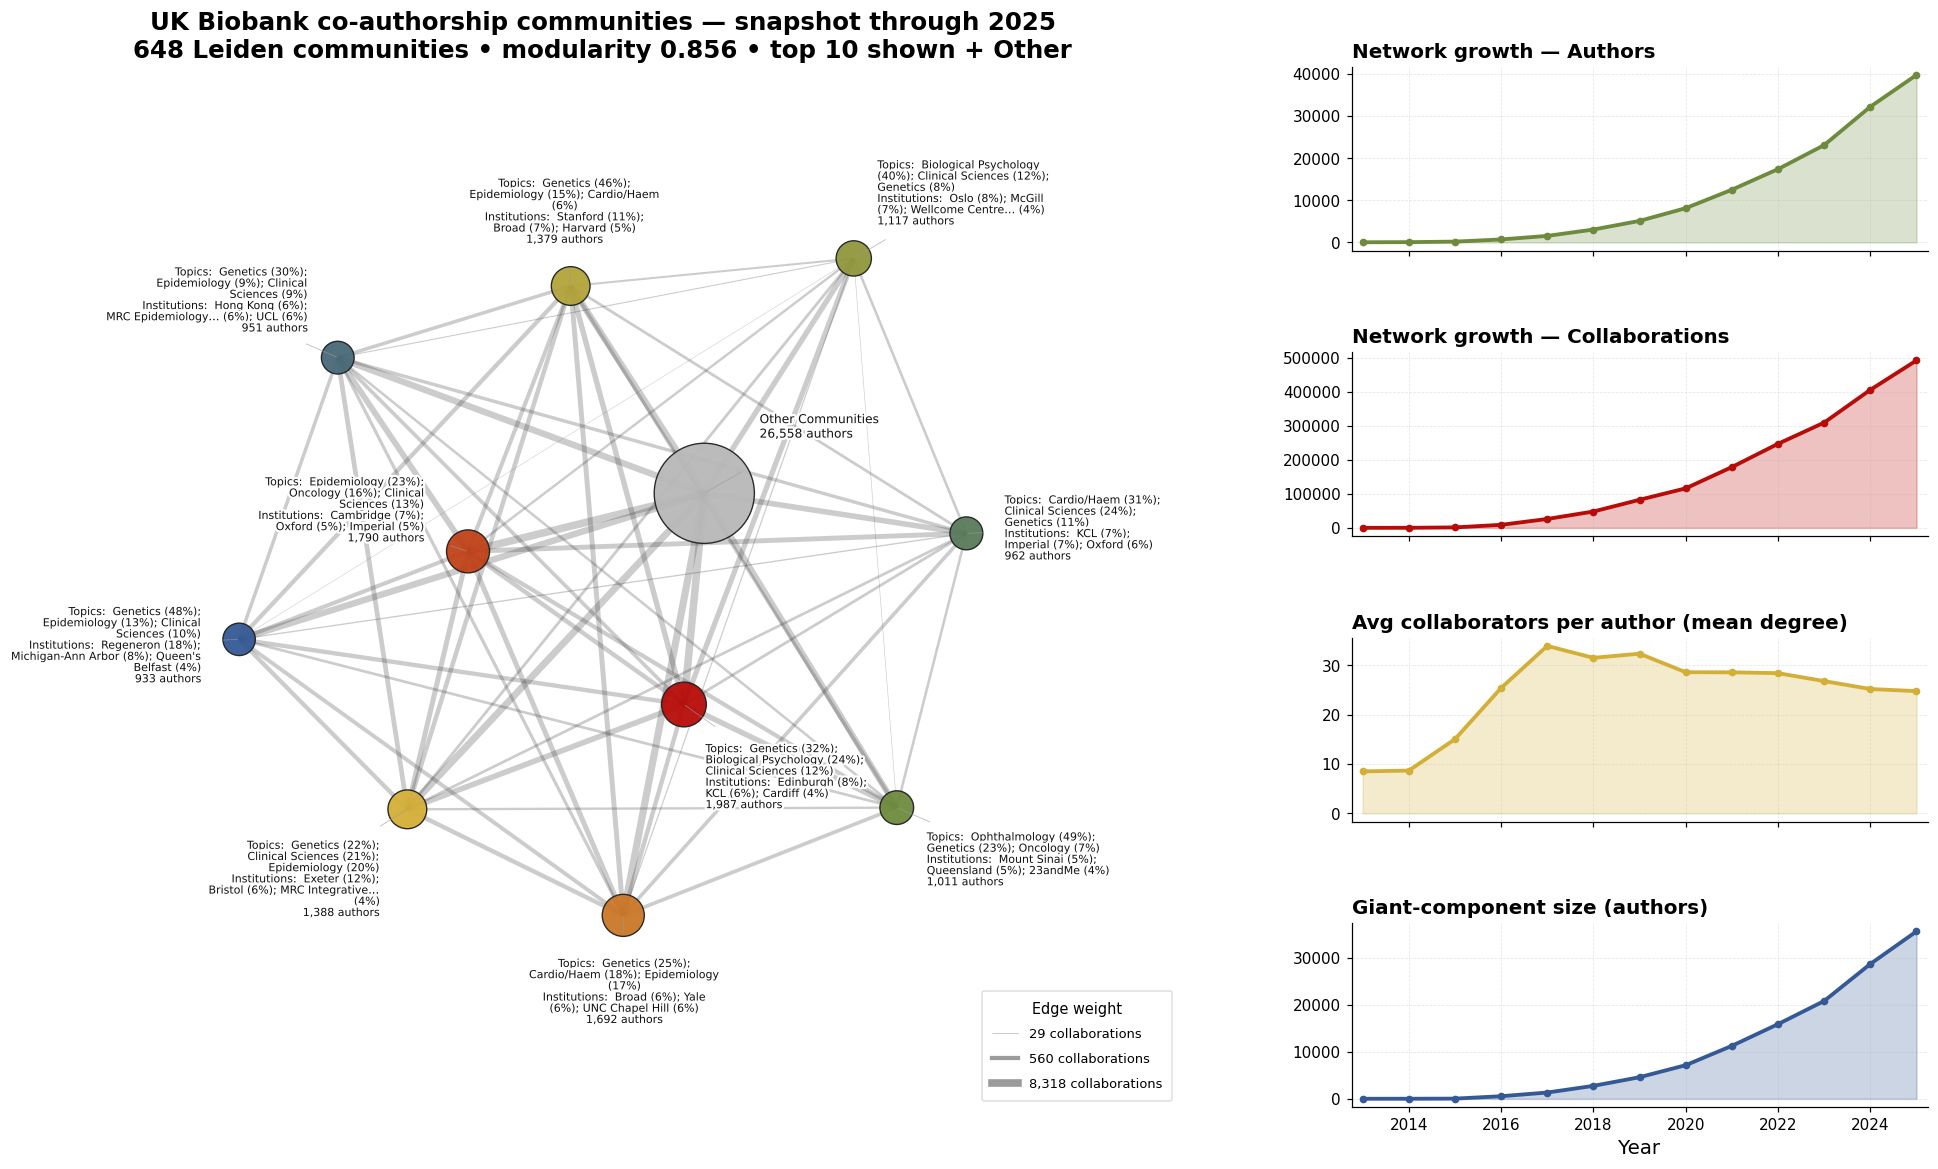

In [22]:
def draw_community_network(ax, plot_graph, modularity, style=STYLE, seed=48652,
                           resolution=1.0,legend=True):
    """Draw the collapsed Leiden community graph onto `ax`: nodes = communities (area
    ∝ √authors, coloured from the project palette; the aggregate Other node is grey),
    edges weighted by inter-community collaborations. Each community's two-line label
    (top-3 topics + top-3 institutions, with shares) is placed OUTSIDE its node — offset
    in screen points along the radial direction with a faint leader line — so the node
    markers stay visible. An edge-weight legend is drawn (node-size legend omitted)."""
    graph = plot_graph.copy()
    for u, v, data in graph.edges(data=True):
        data["layout_weight"] = math.log1p(float(data.get("weight", 1.0)))
    sizes = {n: int(d["size"]) for n, d in graph.nodes(data=True)}
    edge_weights = [float(d.get("weight", 1.0)) for _, _, d in graph.edges(data=True)]

    node_size_scaler = make_value_scaler(sizes.values(), 450, 4300, transform=np.sqrt)
    edge_width_scaler = make_value_scaler(edge_weights, 0.35, 5.0, transform=np.log1p)
    node_areas = {n: node_size_scaler(s) for n, s in sizes.items()}

    k = 1.35 / math.sqrt(max(graph.number_of_nodes(), 1))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        pos = nx.spring_layout(graph, weight="layout_weight", k=k, iterations=900,
                               seed=seed, scale=1.0)
    pos = reduce_node_overlap(pos, node_areas)

    # node colours drawn from the project palette (grey for the aggregate Other node)
    n_top = sum(1 for _, d in graph.nodes(data=True) if not d.get("is_other"))
    comm_palette = extended_palette(max(n_top, 1), style)
    node_colors = []
    for n, d in graph.nodes(data=True):
        if d.get("is_other"):
            node_colors.append("#B8B8B8")
        else:
            node_colors.append(comm_palette[(int(d.get("rank") or 1) - 1) % len(comm_palette)])

    nx.draw_networkx_edges(graph, pos, ax=ax, width=[edge_width_scaler(w) for w in edge_weights],
                           edge_color="#4A4A4A", alpha=0.28)
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=[node_areas[n] for n in graph.nodes()],
                           node_color=node_colors, edgecolors="#202020", linewidths=0.9, alpha=0.95)

    # labels offset OUTSIDE each node (screen-point offset along the radial direction)
    centroid = np.mean(np.array([pos[n] for n in graph.nodes()]), axis=0)
    for n, d in graph.nodes(data=True):
        p = np.array(pos[n], dtype=float)
        vec = p - centroid
        norm = float(np.linalg.norm(vec))
        vec = np.array([0.0, 1.0]) if norm < 1e-6 else vec / norm
        radius_pts = math.sqrt(node_areas[n] / math.pi)   # marker radius in points
        offset = radius_pts + 13
        dx, dy = vec[0] * offset, vec[1] * offset
        ha = "left" if dx > 5 else "right" if dx < -5 else "center"
        va = "bottom" if dy > 5 else "top" if dy < -5 else "center"
        label = f"{d['display_label']}\n{int(d['size']):,} authors"
        ax.annotate(label, xy=p, xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                    fontsize=7.2 if not d.get("is_other") else 8.0, color="#111111",
                    linespacing=1.15, path_effects=[pe.withStroke(linewidth=3.0, foreground="white")],
                    arrowprops=dict(arrowstyle="-", lw=0.5, color="#9A9A9A", alpha=0.7,
                                    shrinkA=radius_pts, shrinkB=1), zorder=5)

    #ax.text(0.0, 0.995,
    #        f"Leiden resolution {resolution:g}; modularity {modularity:.3f}; "
    #        f"{graph.number_of_nodes()} displayed nodes; "
    #        f"{graph.number_of_edges()} displayed inter-community edges",
    #        transform=ax.transAxes, ha="left", va="top", fontsize=10.5, color="#333333")

    # edge-weight legend (node-size legend intentionally omitted)
    if legend:
        edge_handles = [mlines.Line2D([], [], color="#4A4A4A", linewidth=edge_width_scaler(v),
                        alpha=0.55, label=f"{v:,} collaborations") for v in legend_values(edge_weights)]
        if edge_handles:
            ax.legend(handles=edge_handles, title="Edge weight", loc="lower right", frameon=True,
                    framealpha=0.96, facecolor="white", edgecolor="#DDDDDD", fontsize=8.5,
                    title_fontsize=9.5, borderpad=0.8, labelspacing=0.9)
    ax.set_axis_off()
    ax.margins(0.22)


def plot_community_network(plot_graph, modularity, community_summary, slice_label="through 2025",
                           style=STYLE, seed=48652, resolution=1.0, name="community_network"):
    """Standalone publication figure of the collapsed community network."""
    fig, ax = plt.subplots(figsize=(11.5, 9.0))
    draw_community_network(ax, plot_graph, modularity, style, seed, resolution)
    n_comm = int(community_summary["leiden_community"].nunique())
    ax.set_title(f"UK Biobank co-authorship communities ({slice_label})\n"
                 f"{n_comm:,} Leiden communities • modularity {modularity:.3f}",
                 loc="left", fontsize=style["title_fs"], fontweight="bold", pad=22)
    fig.tight_layout()
    savefig(fig, name, style)
    return fig, ax


def plot_network_with_panels(plot_graph, modularity, community_summary, metrics_ot,
                             snapshot_year=2025, style=STYLE, seed=48652, resolution=1.0,
                             name="network_with_panels"):
    """Combined figure: Leiden community network (left, the MAIN plot) + four cumulative
    growth panels (right). Mirrors the layout of 01_analysis_02_network_over_time.ipynb."""
    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(4, 2, width_ratios=[2, 1], hspace=0.55, wspace=0.20,
                          left=0.02, right=0.98, top=0.92, bottom=0.06)

    # ---- left: community-aggregated network (main plot) ----
    ax_net = fig.add_subplot(gs[:, 0])
    draw_community_network(ax_net, plot_graph, modularity, style, seed, resolution)
    n_comm = int(community_summary["leiden_community"].nunique())
    n_top = plot_graph.number_of_nodes() - int(any(
        d.get("is_other") for _, d in plot_graph.nodes(data=True)))
    ax_net.set_title(
        f"UK Biobank co-authorship communities — snapshot through {snapshot_year}\n"
        f"{n_comm:,} Leiden communities • modularity {modularity:.3f} • "
        f"top {n_top} shown + Other",
        fontsize=style["title_fs"], fontweight="bold")

    # ---- right: four cumulative growth panels ----
    panels = [
        ("n_nodes",     "Network growth — Authors",                   style["c_green"]),
        ("n_edges",     "Network growth — Collaborations",            style["c_accent"]),
        ("avg_degree",  "Avg collaborators per author (mean degree)", style["c_gold"]),
        ("giant_nodes", "Giant-component size (authors)",             style["c_primary"]),
    ]
    x = metrics_ot.index
    for i, (col, title, c) in enumerate(panels):
        ax = fig.add_subplot(gs[i, 1])
        ax.plot(x, metrics_ot[col], color=c, linewidth=2.5, marker="o", markersize=4)
        ax.fill_between(x, 0, metrics_ot[col], color=c, alpha=0.25)
        ax.set_title(title, fontsize=style["label_fs"], fontweight="bold", loc="left", pad=6)
        ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
        ax.tick_params(labelsize=style["tick_fs"] - 1)
        ax.margins(x=0.02)
        if i < len(panels) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Year")
    savefig(fig, name, style)
    return fig


fig = plot_network_with_panels(plot_community_graph, leiden_modularity, community_summary_df,
                               metrics_ot, snapshot_year=2025)
plt.show()


### Community structure — how many communities, and what they are

Leiden returns **648 communities**, but that count is dominated by the graph's **540
connected components**: one giant component holds **89.6%** of authors, and the other ~539
are **tiny isolated author teams** (pairs/triples on niche papers) which — being
disconnected — are each *forced* to be their own community. The **real thematic structure is
the ~109 communities inside the giant component**; only **60 have ≥100 authors**, the median
community has just **7**, and the **top 20 cover ~52%** of all authors.

The plot above shows the 10 largest. The table below exposes the full per-community
information those labels can only hint at — size, author share, and the top-3 FOR research
topics and institutions (author-weighted). It is also where Oxford's strongholds surface: as
the UK Biobank hub it is diffuse (a strong #2/#3 across the big clusters), and it actually
*leads* two communities ranked #18 and #22, below the plot's top-10 cutoff.

> To coarsen the partition, lower `LEIDEN_RESOLUTION` (fewer, larger communities within the
> giant); the ~539 disconnected tiny teams cannot be merged at any resolution. Switch topic
> granularity with `COMMUNITY_TOPIC_COL` (`_l4` ↔ `_l2`).

In [23]:
# Full community information the plot can only summarise:
#   (a) a size/provenance report that explains the community count, and
#   (b) a per-community table of topics + institutions (author-weighted shares).
# Reuses comm_topic_counts / comm_inst_counts already built in the driver above.
from IPython.display import display

print("Community structure — size & provenance")
display(community_size_report(author_comm, AA, resolution=LEIDEN_RESOLUTION))

print("\nTop-20 communities — topics & institutions (author-weighted shares)")
community_summary_table(author_comm, comm_topic_counts, comm_inst_counts,
                        topic_col=COMMUNITY_TOPIC_COL, n_items=3, top=20)


Community structure — size & provenance


,metric,value,note
0,Authors (graph nodes),"39,768",
1,Connected components,540,"giant holds 35,614 (89.6%)"
2,...tiny teams (<=5 authors),241,isolated groups; each forced to be its own com...
3,Leiden communities (total),648,resolution 1
4,...within the giant component,109,the real thematic structure
5,...with >= 100 authors,60,hold 85% of authors
6,...with < 5 authors,169,mostly the tiny disconnected teams
7,Median community size,7,authors
8,Top-10 communities cover,33.2%,of all authors
9,Top-20 communities cover,52.1%,of all authors



Top-20 communities — topics & institutions (author-weighted shares)


,rank,n_authors,pct,cum_pct,top_topics,top_institutions
0,1,1987,5.0,5.0,Genetics (32%); Biological Psychology (24%); C...,Edinburgh (8%); KCL (6%); Cardiff (4%)
1,2,1790,4.5,9.5,Epidemiology (23%); Oncology (16%); Clinical S...,Cambridge (7%); Oxford (5%); Imperial (5%)
2,3,1692,4.3,13.8,Genetics (25%); Cardio/Haem (18%); Epidemiolog...,Broad (6%); Yale (6%); UNC Chapel Hill (6%)
3,4,1388,3.5,17.3,Genetics (22%); Clinical Sciences (21%); Epide...,Exeter (12%); Bristol (6%); MRC Integrative… (4%)
4,5,1379,3.5,20.8,Genetics (46%); Epidemiology (15%); Cardio/Hae...,Stanford (11%); Broad (7%); Harvard (5%)
5,6,1117,2.8,23.6,Biological Psychology (40%); Clinical Sciences...,Oslo (8%); McGill (7%); Wellcome Centre… (4%)
6,7,1011,2.5,26.1,Ophthalmology (49%); Genetics (23%); Oncology ...,Mount Sinai (5%); Queensland (5%); 23andMe (4%)
7,8,962,2.4,28.5,Cardio/Haem (31%); Clinical Sciences (24%); Ge...,KCL (7%); Imperial (7%); Oxford (6%)
8,9,951,2.4,30.9,Genetics (30%); Epidemiology (9%); Clinical Sc...,Hong Kong (6%); MRC Epidemiology… (6%); UCL (6%)
9,10,933,2.3,33.2,Genetics (48%); Epidemiology (13%); Clinical S...,Regeneron (18%); Michigan-Ann Arbor (8%); Quee...


## 7. Combined figure for the paper

The four headline results assembled into a single 2x2 panel for the manuscript:
**(a)** geographic distribution of papers (NON-fractional — whole distinct-paper count
per country, author-affiliation basis), **(b)** the most prolific institutions, **(c)**
gender trends (authorship volume + female share), and **(d)** the Leiden co-authorship
communities. Each panel calls the *same* draw routine as its section above (via a new
`ax=`/`axes=` argument), so the composite never drifts from the individual figures. Set
`STYLE['save']=True` to write it to `fig/authors/paper_combined.pdf`.

In [69]:
inst_totals

,org_name,papers,authors,country
0,University of Oxford,315.324742,754,United Kingdom
1,University of Glasgow,230.674172,259,United Kingdom
2,Tongji Medical College of Huazhong University ...,139.315877,330,China
3,Fudan University,139.117571,400,China
4,University of Edinburgh,134.626479,318,United Kingdom
5,University College London,131.792307,385,United Kingdom
6,Sun Yat-sen University,130.949153,485,China
7,University of Cambridge,126.904741,381,United Kingdom
8,Southern Medical University,125.243137,498,China
9,King's College London,125.136401,362,United Kingdom


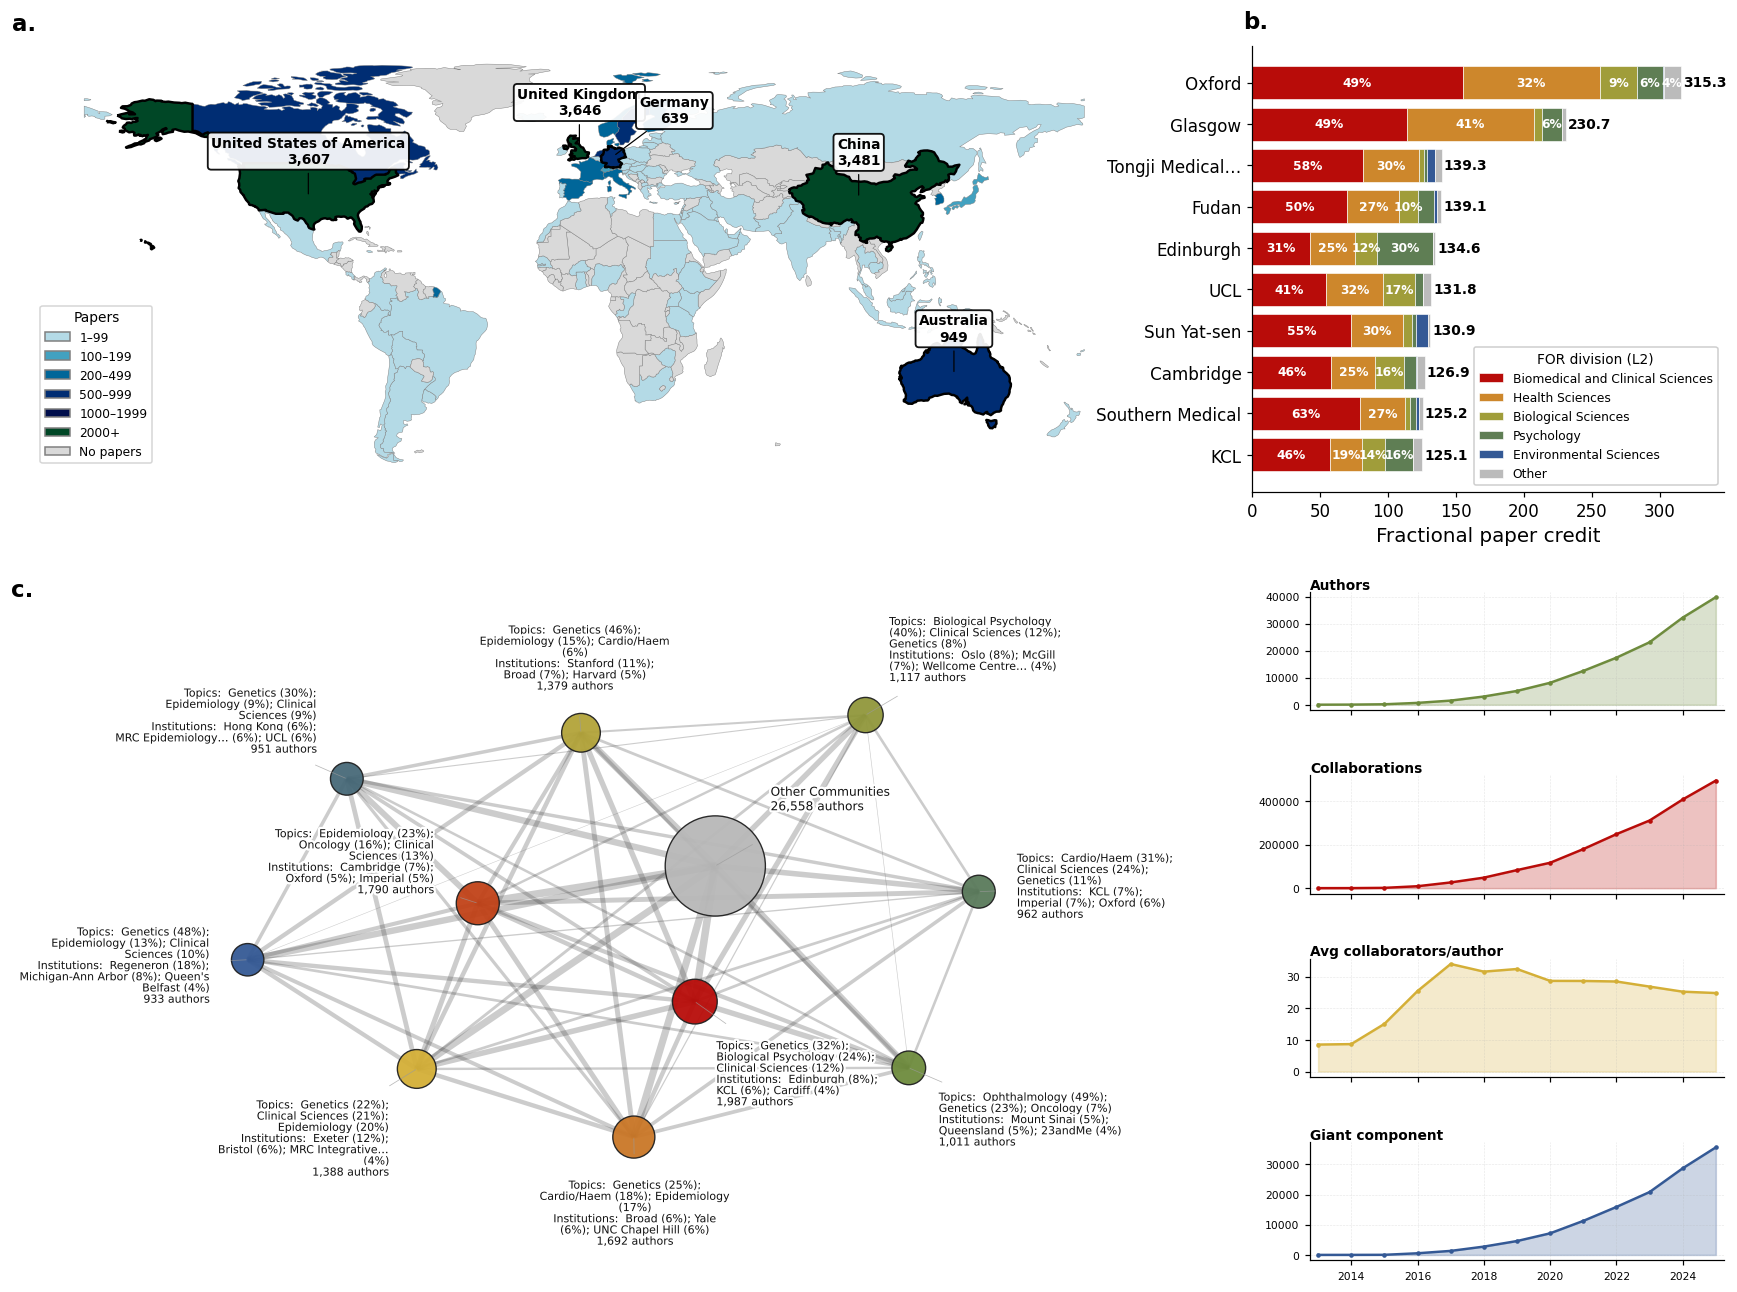

In [75]:
def plot_paper_figure(country_df, inst_totals, inst_breakdown,
                      plot_community_graph, leiden_modularity, metrics_ot,
                      style=STYLE, n_institutes=10, name="paper_combined"):
    """Assemble THREE results into one publication figure:
      (a) geographic distribution — NON-fractional (distinct papers per country),
      (b) top institutions (stacked by FOR L2 division; %-annotated segments),
      (c) authorship networks — Leiden communities + four cumulative growth panels.
    Layout: top row = map (a) + institutions (b); bottom row = the network (c), full width.
    Each panel reuses the same draw function as its standalone section."""
    cstyle = {**style, "title_fs": 13, "label_fs": 11, "tick_fs": 9,
              "annot_fs": 9, "legend_fs": 9}

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.18, wspace=0.15,
                          height_ratios=[0.4, 0.6], width_ratios=[0.7, 0.3],
                          left=0.02, right=0.98, top=0.96, bottom=0.04)

    # (a) geography — NON-fractional whole distinct-paper count per country (top-left)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_a.set_anchor("N")
    plot_country_map(country_df, value_col="papers", label="Papers", title=" ",
                     annotate_top=5, bins=PAPER_BINS, bin_labels=PAPER_BIN_LABELS,
                     style=cstyle, ax=ax_a)

    # (b) top institutions — top-N with names shortened (top-right)
    ax_b = fig.add_subplot(gs[0, 1])
    keep = inst_totals.head(n_institutes)["org_name"]
    _short = lambda s: _short_institution_label(s, width=18)
    it = inst_totals.head(n_institutes).copy()
    it["org_name"] = it["org_name"].map(_short)
    ib = inst_breakdown[inst_breakdown["org_name"].isin(keep)].copy()
    ib["org_name"] = ib["org_name"].map(_short)
    plot_top_institutes(it, ib, n_for=5, style=cstyle, normalize=True, title=" ", ax=ax_b)

    # (c) authorship networks — full bottom row: community network (left) + growth panels (right)
    gs_c = gs[1, :].subgridspec(4, 2, width_ratios=[2.8, 1], hspace=0.55, wspace=0.15)
    ax_d = fig.add_subplot(gs_c[:, 0])
    draw_community_network(ax_d, plot_community_graph, leiden_modularity, style=cstyle, legend=False)
    ax_d.set_title(" ", fontsize=cstyle["title_fs"], fontweight="bold")
    growth = [("n_nodes", "Authors", cstyle["c_green"]),
              ("n_edges", "Collaborations", cstyle["c_accent"]),
              ("avg_degree", "Avg collaborators/author", cstyle["c_gold"]),
              ("giant_nodes", "Giant component", cstyle["c_primary"])]
    gx = metrics_ot.index
    for i, (col, gt, gc) in enumerate(growth):
        axg = fig.add_subplot(gs_c[i, 1])
        axg.plot(gx, metrics_ot[col], color=gc, linewidth=1.6, marker="o", markersize=2)
        axg.fill_between(gx, 0, metrics_ot[col], color=gc, alpha=0.25)
        axg.set_title(gt, fontsize=cstyle["tick_fs"], fontweight="bold", loc="left", pad=2)
        axg.grid(alpha=0.3, linestyle="--", linewidth=0.4)
        axg.tick_params(labelsize=cstyle["tick_fs"] - 2)
        axg.margins(x=0.02)
        if i < len(growth) - 1:
            axg.set_xticklabels([])

    # panel letters (a. b. c.) at the top-left of each panel
    for ax, letter, dy in zip([ax_a, ax_b, ax_d], ["a.", "b.", "c."], [1.08, 1.08, 1.02]):
        ax.text(-0.02, dy, letter, transform=ax.transAxes, ha="left", va="top",
                fontsize=cstyle["title_fs"] + 2, fontweight="bold")
    savefig(fig, name, style)
    return fig


fig = plot_paper_figure(country_df, inst_totals, inst_breakdown,
                        plot_community_graph, leiden_modularity, metrics_ot)
plt.show()


## Next step — modularisation

Once the analysis is settled, lift the function cells above into
`src/utils/author_utils.py` (one module, mirroring `utils/patent_utils.py`) and
replace them here with:

```python
from utils import author_utils as authors
```

The functions are already pure and `STYLE`-driven, so the move is mechanical:
`parse_listcol`, `pick_main_affiliation`, `build_author_paper_table`, `missing_report`,
`_split_for_name`, `build_for_lookup`,
`build_paper_for_table`, `build_grid_lookup`, `enrich_affiliations`, `build_author_summary`, `to_iso3`,
`build_country_counts`,
`build_country_counts_orgbasis`, `plot_country_map`, `top_institutes`,
`plot_top_institutes`, `infer_gender`, `assign_gender`,
`gender_over_time`, `plot_gender_trends`, `build_coauthor_matrix`, `network_summary`, `network_metrics_over_time`,
`detect_leiden_communities`, `build_full_community_graph`, `collapse_community_graph`,
`make_topic_summary_by_group`, `make_institution_summary_by_group`, `apply_community_labels`,
`make_value_scaler`, `reduce_node_overlap`, `draw_community_network`,
`community_size_report`, `community_summary_table`,
`plot_community_network`, `plot_network_with_panels`, `plot_paper_figure` — plus `load_dimensions`, the
`STYLE` dict / `apply_style` / `extended_palette`.